# 📊 PROJET CRISP-DM : Analyse et Prédiction des Temps de Livraison

---

## 🎯 PHASE 1 : BUSINESS UNDERSTANDING (Compréhension Métier)

### Contexte du Projet
Analyse du dataset `datadelevry.xlsx` pour optimiser les opérations logistiques d'un service de livraison.

### Objectifs Métiers (Business Objectives)

**BO1 : Prédire le temps de livraison**
- Estimer précisément combien de temps prendra chaque livraison
- Fournir un horaire fiable aux clients
- Réduire les frustrations et améliorer la satisfaction globale

**BO2 : Segmentation des commandes (Clustering)**
- Regrouper les commandes en groupes similaires
- Mieux organiser et assigner les livreurs
- Améliorer l'efficacité logistique

**BO3 : Réduction de dimensionnalité**
- Simplifier les données en résumant les informations clés
- Réduire le nombre de variables sans perte significative d'information
- Faciliter les analyses futures

### Traduction en Objectifs Data Science

**Pour BO1 : Régression Supervisée**
- Variable cible : temps de livraison (différence en minutes entre `actual_delivery_time` et `created_at`)
- Features : `market_id`, `store_primary_category`, `total_items`, `subtotal`, `total_onshift_partners`
- Modèles : Régression linéaire, Random Forest, Gradient Boosting
- Métriques : MAE, RMSE, R²

**Pour BO2 : Clustering Non Supervisé**
- Features : `market_id`, `created_at`, `total_items`, `total_outstanding_orders`
- Algorithmes : K-means, DBSCAN
- Validation : Elbow method, Silhouette score

**Pour BO3 : Réduction de Dimensionnalité**
- Features numériques : `subtotal`, `min_item_price`, `max_item_price`, etc.
- Objectif : Conserver 80-90% de variance
- Algorithmes : PCA, t-SNE
- Prétraitement : Normalisation, imputation

---

## 📁 PHASE 2 : DATA UNDERSTANDING (Compréhension des Données)

### Objectif
Explorer et comprendre le dataset pour identifier les patterns, anomalies et relations entre les variables.

### Étapes
1. **Chargement des données** : Import du fichier Excel
2. **Exploration initiale** : Structure, dimensions, types de données
3. **Analyse descriptive** : Statistiques, distributions, corrélations
4. **Visualisations** : Graphiques pour comprendre les patterns
5. **Détection d'anomalies** : Outliers, valeurs manquantes

---


##  Chargement des librairies et définition du chemin du fichier
Cette cellule importe les librairies nécessaires (pandas, numpy, matplotlib, etc.) et définit le chemin du fichier de données à analyser.


In [1]:

# 1) Setup - imports et chemin du fichier
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from IPython.display import display

# Chemin du fichier Excel - modifie si nécessaire
FILE_PATH = 'datadelevry.xlsx'
print('FILE_PATH =', FILE_PATH)
print('Working dir:', os.getcwd())


ModuleNotFoundError: No module named 'matplotlib'

## Lecture du fichier Excel
Cette cellule lit le fichier Excel, gère le cas où toutes les données sont dans une seule colonne, détecte et applique l’en-tête si besoin, puis affiche les premières lignes du jeu de données.


In [4]:

# 2) Lecture du fichier Excel
if not os.path.exists(FILE_PATH):
    raise FileNotFoundError(f"Fichier non trouvé: {FILE_PATH}")

# Lire sans header pour gérer le cas "tout dans une seule colonne"
df_raw = pd.read_excel(FILE_PATH, header=None)
print('Raw shape:', df_raw.shape)

if df_raw.shape[1] == 1:
    print('Fichier avec une seule colonne détecté -> split par virgule')
    df = df_raw[0].astype(str).str.split(',', expand=True)
    # Détecter si la première ligne contient les noms de colonnes
    first_row = df.iloc[0].astype(str).str.lower().tolist()
    if any('created' in s or 'actual' in s or 'store' in s for s in first_row):
        df.columns = df.iloc[0]
        df = df[1:].reset_index(drop=True)
        print('En-tête détectée et appliquée. Nouvelle forme :', df.shape)
    else:
        df.columns = [f'col_{i}' for i in range(df.shape[1])]
        print('Aucun en-tête détecté ; colonnes génériques appliquées. Nouvelle forme :', df.shape)
else:
    df = df_raw.copy()
    # S'assurer que les noms de colonnes sont des strings propres
    df.columns = [str(c).strip() for c in df.columns]
    print('Fichier multi-colonnes chargé. Shape:', df.shape)

display(df.head(8))



NameError: name 'os' is not defined

##  Affichage des noms de colonnes
Cette cellule affiche la liste des colonnes et la résumé des manquants et détection simple d'outliers.


In [5]:
print('Colonnes  :')
print(df.columns.tolist())
display(df.head(5))
#  Résumé des manquants et détection simple d'outliers
missing_summary = df.isna().mean().round(3) * 100
print('Pourcentage de valeurs manquantes par colonne (%):')
display(missing_summary.sort_values(ascending=False).head(30))


Colonnes  :


NameError: name 'df' is not defined

In [218]:
numeric_cols = [
    "market_id", "total_items", "subtotal", "num_distinct_items",
    "min_item_price", "max_item_price",
    "total_onshift_partners", "total_busy_partners", "total_outstanding_orders"
]
for c in numeric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c].replace('', pd.NA), errors='coerce')

print('Types des colonnes numériques:')
print(df[numeric_cols].dtypes)

# Pour afficher les colonnes non numériques :
non_numeric_cols = [col for col in df.columns if col not in numeric_cols]
print('Types des colonnes non numériques:')
print(df[non_numeric_cols].dtypes)


Types des colonnes numériques:
0
market_id                   float64
total_items                 float64
subtotal                    float64
num_distinct_items          float64
min_item_price              float64
max_item_price              float64
total_onshift_partners      float64
total_busy_partners         float64
total_outstanding_orders    float64
dtype: object
Types des colonnes non numériques:
0
created_at                object
actual_delivery_time      object
store_id                  object
store_primary_category    object
order_protocol            object
dtype: object


In [6]:
print(df[non_numeric_cols].dtypes)
print(df[numeric_cols].dtypes)


NameError: name 'df' is not defined

In [220]:
categorical_cols = [
    "store_id", "store_primary_category", "order_protocol"
]  # Remplacez par vos colonnes catégorielles réelles, par ex. basées sur les non_numeric_cols

for c in categorical_cols:
    if c in df.columns:
        df[c] = df[c].replace('', pd.NA).astype('category')

print('Types des colonnes catégorielles:')
print(df[categorical_cols].dtypes)

# Pour vérifier les autres colonnes si nécessaire (ex. datetime)
other_cols = [col for col in df.columns if col not in numeric_cols + categorical_cols]
if other_cols:
    print('Types des autres colonnes (ex. datetime potentiellement):')
    print(df[other_cols].dtypes)

Types des colonnes catégorielles:
0
store_id                  category
store_primary_category    category
order_protocol            category
dtype: object
Types des autres colonnes (ex. datetime potentiellement):
0
created_at              object
actual_delivery_time    object
dtype: object


In [7]:
import pandas as pd

# Assuming df is your DataFrame, load it if necessary
# For example:
# df = pd.read_csv('your_file.csv')  # Replace with your actual data loading

datetime_cols = [
    "created_at", "actual_delivery_time"
]  # Les deux variables de type date

for c in datetime_cols:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors='coerce')

print('Types des colonnes datetime:')
print(df[datetime_cols].dtypes)

# Pour vérifier les autres colonnes si nécessaire
other_cols = [col for col in df.columns if col not in numeric_cols + categorical_cols + datetime_cols]
if other_cols:
    print('Types des autres colonnes:')
    print(df[other_cols].dtypes)

NameError: name 'df' is not defined

In [222]:

# 6) Résumé des manquants et détection simple d'outliers
missing_summary = df.isna().mean().round(3) * 100
print('Pourcentage de valeurs manquantes par colonne (%):')
display(missing_summary.sort_values(ascending=False).head(30))

Pourcentage de valeurs manquantes par colonne (%):


0
total_onshift_partners      10.0
total_busy_partners         10.0
total_outstanding_orders    10.0
store_primary_category       4.4
market_id                    2.5
order_protocol               2.5
created_at                   2.0
actual_delivery_time         2.0
store_id                     2.0
total_items                  2.0
num_distinct_items           2.0
min_item_price               2.0
max_item_price               2.0
subtotal                     1.9
dtype: float64

,count,mean,std,min,25%,50%,75%,max
0,,,,,,,,
market_id,168654.0,2.982414,1.525751,1.0,2.0,3.0,4.0,6.0
total_items,169453.0,3.201543,2.674022,1.0,2.0,3.0,4.0,411.0
subtotal,169660.0,2684.534174,1824.565715,0.0,1400.0,2200.0,3397.0,27100.0
num_distinct_items,169489.0,2.678699,1.634766,1.0,1.0,2.0,3.0,20.0
min_item_price,169472.0,684.503009,520.492937,-86.0,299.0,595.0,945.0,14700.0
max_item_price,169521.0,1159.144708,560.203570,0.0,799.0,1095.0,1395.0,14700.0
total_onshift_partners,155613.0,44.813216,34.536004,-3.0,17.0,37.0,65.0,171.0
total_busy_partners,155590.0,41.809801,32.187008,-5.0,15.0,34.0,62.0,154.0
total_outstanding_orders,155624.0,58.090224,52.728748,-6.0,17.0,41.0,85.0,285.0


Statistiques de la variable cible (calculée à la volée) :
count    166144.000000
mean         48.653734
std         348.927631
min           1.683333
25%          35.150000
50%          44.416667
75%          56.433333
max      141947.650000
dtype: float64

Valeurs négatives : 0


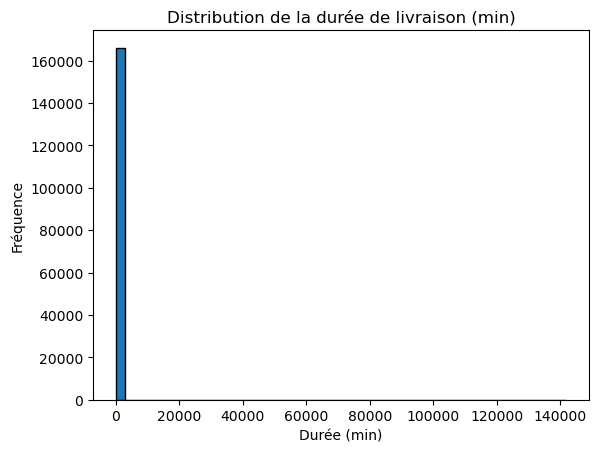


Percentiles target:


,value
0.01,19.233333
0.05,24.900000
0.25,35.150000
0.50,44.416667
0.75,56.433333
0.95,81.283333
0.99,108.259500


In [ ]:
# 7) Statistiques descriptives numériques
num_stats = df.select_dtypes(include=[np.number]).describe().T
display(num_stats[['count','mean','std','min','25%','50%','75%','max']])
# Vérification des données nécessaires
if 'created_at' in df.columns and 'actual_delivery_time' in df.columns:
    # Conversion temporaire en datetime (sans infer_datetime_format)
    created_at = pd.to_datetime(df['created_at'], errors='coerce')
    actual_delivery_time = pd.to_datetime(df['actual_delivery_time'], errors='coerce')
    

    # Analyse statistique
    print("Statistiques de la variable cible (calculée à la volée) :")
    print(((actual_delivery_time - created_at).dt.total_seconds() / 60.0).describe())

    # Vérification des valeurs aberrantes
    print("\nValeurs négatives :", (((actual_delivery_time - created_at).dt.total_seconds() / 60.0) < 0).sum())

    # Histogramme
    import matplotlib.pyplot as plt
    
    # Analyse des percentiles à la volée
    print('\nPercentiles target:')
    display(((actual_delivery_time - created_at).dt.total_seconds() / 60.0).quantile([0.01,0.05,0.25,0.5,0.75,0.95,0.99]).to_frame('value'))
else:
    print("Les colonnes nécessaires n'existent pas pour analyser la variable cible.")


In [224]:

# 9) Matrice de corrélation (numérique)
num_df = df.select_dtypes(include=[np.number])
if num_df.shape[1] >= 2:
    corr = num_df.corr().round(3)
    display(corr)
    
else:
    print('Pas assez de colonnes numériques pour corrélations.')
if 'created_at' in df.columns and 'actual_delivery_time' in df.columns:
    # Conversion en datetime
    created_at = pd.to_datetime(df['created_at'], errors='coerce')
    actual_delivery_time = pd.to_datetime(df['actual_delivery_time'], errors='coerce')
    
    
    # Sélection des colonnes numériques
    numeric_cols = df.select_dtypes(include=['int64','float64']).columns
    
    if len(numeric_cols) > 0:
        print('\nCorrélations avec la cible (calculée à la volée) :')
        correlations = df[numeric_cols].corrwith(((actual_delivery_time - created_at).dt.total_seconds() / 60.0))
        print(correlations.sort_values(ascending=False))
    else:
        print('Pas assez de colonnes numériques pour calculer les corrélations.')
else:
    print("'created_at' ou 'actual_delivery_time' manquant → impossible de calculer les corrélations.")
    


,market_id,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders
0,,,,,,,,,
market_id,1.000,-0.002,-0.012,0.009,-0.003,-0.003,0.069,0.060,0.062
total_items,-0.002,1.000,0.556,0.760,-0.390,-0.056,0.033,0.030,0.036
subtotal,-0.012,0.556,1.000,0.679,0.040,0.511,0.132,0.128,0.132
num_distinct_items,0.009,0.760,0.679,1.000,-0.448,0.043,0.068,0.064,0.071
min_item_price,-0.003,-0.390,0.040,-0.448,1.000,0.545,0.039,0.041,0.037
max_item_price,-0.003,-0.056,0.511,0.043,0.545,1.000,0.130,0.129,0.128
total_onshift_partners,0.069,0.033,0.132,0.068,0.039,0.130,1.000,0.944,0.936
total_busy_partners,0.060,0.030,0.128,0.064,0.041,0.129,0.944,1.000,0.933
total_outstanding_orders,0.062,0.036,0.132,0.071,0.037,0.128,0.936,0.933,1.000



Corrélations avec la cible (calculée à la volée) :
0
total_outstanding_orders    0.145907
total_busy_partners         0.075851
total_onshift_partners      0.059618
subtotal                    0.010171
max_item_price              0.009135
num_distinct_items          0.005661
min_item_price              0.005297
total_items                 0.004098
market_id                  -0.005777
dtype: float64


In [225]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import itertools

# Liste des colonnes catégorielles
categorical_cols = ["store_id", "store_primary_category", "order_protocol"]

# Fonction pour calculer Cramer's V
def cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(k, r) - 1)))

# Créer une matrice vide
cramers_results = pd.DataFrame(
    np.zeros((len(categorical_cols), len(categorical_cols))),
    index=categorical_cols,
    columns=categorical_cols
)

# Calculer Cramer's V pour chaque paire de colonnes
for col1, col2 in itertools.combinations(categorical_cols, 2):
    confusion_matrix = pd.crosstab(df[col1], df[col2])
    v = cramers_v(confusion_matrix)
    cramers_results.loc[col1, col2] = v
    cramers_results.loc[col2, col1] = v

# Mettre 1 sur la diagonale
np.fill_diagonal(cramers_results.values, 1)

print("Matrice de corrélation Cramer's V :")
display(cramers_results)


Matrice de corrélation Cramer's V :


,store_id,store_primary_category,order_protocol
store_id,1.000000,0.955996,0.860345
store_primary_category,0.955996,1.000000,0.319227
order_protocol,0.860345,0.319227,1.000000


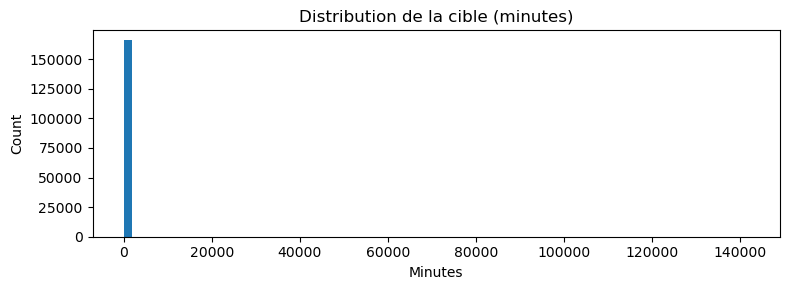

Percentiles:
{0.01: 19.233333333333334, 0.05: 24.9, 0.25: 35.15, 0.5: 44.416666666666664, 0.75: 56.43333333333333, 0.95: 81.28333333333333, 0.99: 108.25950000000012}


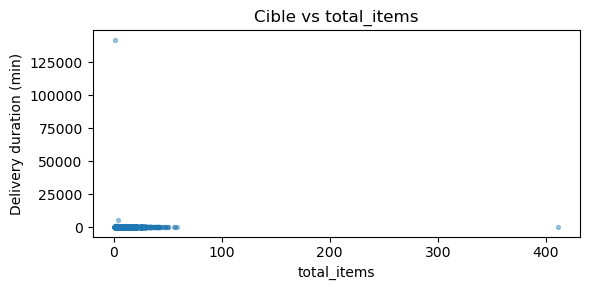

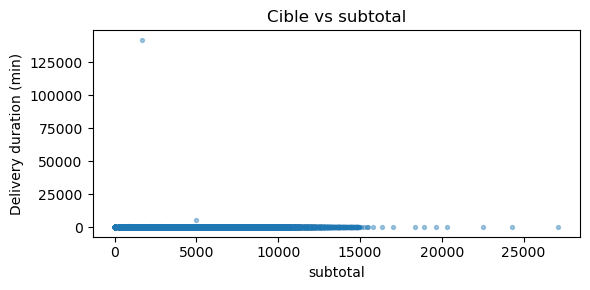

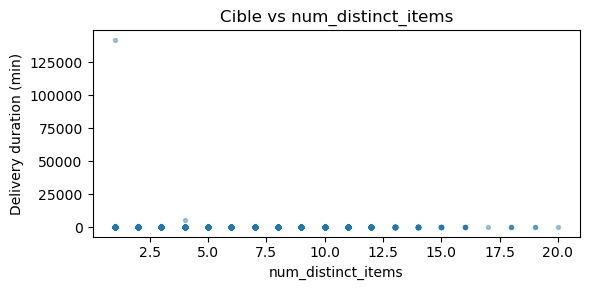

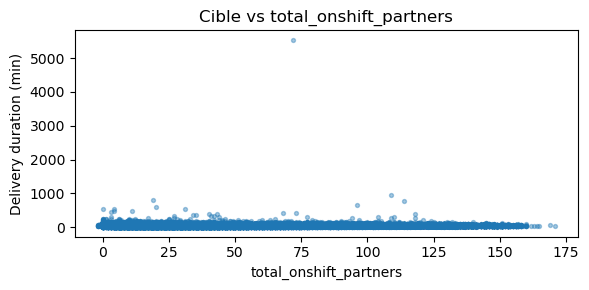

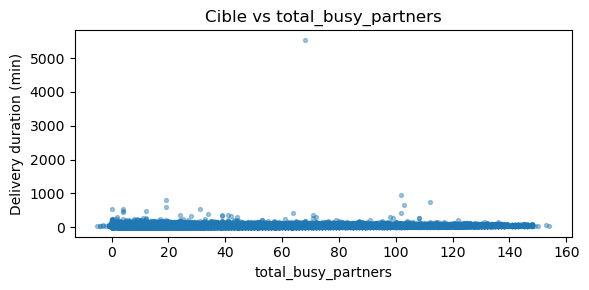

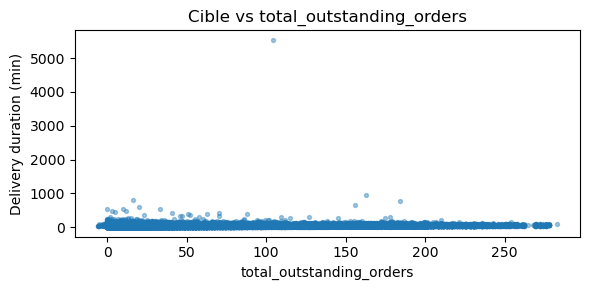

In [226]:
import matplotlib.pyplot as plt

if 'created_at' in df.columns and 'actual_delivery_time' in df.columns:
    # Conversion en datetime
    created_at = pd.to_datetime(df['created_at'], errors='coerce')
    actual_delivery_time = pd.to_datetime(df['actual_delivery_time'], errors='coerce')
    
    # Variable cible calculée à la volée
    target_temp = (actual_delivery_time - created_at).dt.total_seconds() / 60.0
    data = target_temp.dropna()

    # Histogramme cible
    plt.figure(figsize=(8,3))
    plt.hist(data, bins=80)
    plt.title('Distribution de la cible (minutes)')
    plt.xlabel('Minutes'); plt.ylabel('Count'); plt.tight_layout()
    plt.show()

    # Percentiles
    print('Percentiles:')
    print(data.quantile([0.01,0.05,0.25,0.5,0.75,0.95,0.99]).to_dict())

    # Scatter target vs features
    features_to_plot = [c for c in ['total_items','subtotal','num_distinct_items',
                                   'total_onshift_partners','total_busy_partners',
                                   'total_outstanding_orders'] if c in df.columns]

    if len(features_to_plot):
        for c in features_to_plot:
            plt.figure(figsize=(6,3))
            plt.scatter(df[c], target_temp, s=8, alpha=0.4)
            plt.title(f'Cible vs {c}')
            plt.xlabel(c); plt.ylabel('Delivery duration (min)')
            plt.tight_layout(); plt.show()
else:
    print("'created_at' ou 'actual_delivery_time' manquant → impossible d'analyser la cible.")


In [227]:
cat_cols = [c for c in df.columns if df[c].dtype == object or df[c].dtype.name == 'category']
for c in cat_cols:
    print(f"\nColonne: {c} (top 10 valeurs)")
    col = df[c]
    if isinstance(col.dtype, pd.CategoricalDtype):
        col = col.cat.add_categories('NaN').fillna('NaN')
    else:
        col = col.fillna('NaN')
    display(col.astype(str).value_counts().head(10))


Colonne: store_id (top 10 valeurs)


store_id
NaN                                 3452
d43ab110ab2489d6b9b2caa394bf920f     918
757b505cfd34c64c85ca5b5690ee5293     839
faacbcd5bf1d018912c116bf2783e9a1     802
45c48cce2e2d7fbdea1afc51c7c6ad26     704
c9f0f895fb98ab9159f51fd0297e236d     584
dc5689792e08eb2e219dce49e64c885b     542
fbd7939d674997cdb4692d34de8633c4     527
f7177163c833dff4b38fc8d2872f1ec6     524
f15d337c70078947cfe1b5d6f0ed3f13     520
Name: count, dtype: int64


Colonne: store_primary_category (top 10 valeurs)


store_primary_category
american    16736
pizza       14916
mexican     14005
burger       9909
japanese     8242
sandwich     8213
chinese      8038
NaN          7572
dessert      7182
italian      6424
Name: count, dtype: int64


Colonne: order_protocol (top 10 valeurs)


order_protocol
1.0    47283
3.0    46456
5.0    35922
2.0    21381
4.0    16952
NaN     4310
6.0      618
7.0       19
Name: count, dtype: int64

In [228]:

# 12) Recommandations et exemples d'imputation
print('Colonnes avec >30% de NA (à investiguer) :')
missing_summary = df.isna().mean().round(3) * 100
display(missing_summary[missing_summary > 30])

# Exemple d'imputation simple (décommente pour appliquer)
# numeric_cols_present = [c for c in numeric_cols if c in df.columns]
# for c in numeric_cols_present:
#     df[c].fillna(df[c].median(), inplace=True)
# for c in cat_cols:
#     df[c].fillna('unknown', inplace=True)

Colonnes avec >30% de NA (à investiguer) :


Series([], dtype: float64)

## Détection des doublons
Cette cellule détecte et affiche le nombre de lignes dupliquées dans le jeu de données.


In [230]:
# 15) Détection des doublons
nb_total = len(df)
nb_duplicated = df.duplicated().sum()
print(f"Nombre de doublons (lignes identiques) : {nb_duplicated} sur {nb_total} lignes ({100*nb_duplicated/nb_total:.2f}%)")
if nb_duplicated > 0:
    display(df[df.duplicated()].head())



Nombre de doublons (lignes identiques) : 105 sur 172941 lignes (0.06%)


,market_id,created_at,actual_delivery_time,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders
172836,1.0,2015-01-30 05:23:32,2015-01-30 06:00:17,86df7dcfd896fcaf2674f757a2463eba,breakfast,3.0,2.0,1145.0,2.0,250.0,895.0,13.0,16.0,19.0
172837,NaN,2015-01-24 01:48:01,2015-01-24 02:21:37,320722549d1751cf3f247855f937b982,steak,2.0,1.0,895.0,1.0,895.0,895.0,88.0,82.0,NaN
172838,2.0,2015-02-01 02:11:02,2015-02-01 03:06:31,37c9bc66ebd3a2e455ee2a74feae4c0e,japanese,5.0,2.0,1940.0,2.0,945.0,995.0,105.0,NaN,165.0
172839,4.0,2015-02-08 03:14:37,2015-02-08 04:04:13,8f14e45fceea167a5a36dedd4bea2543,mediterranean,3.0,NaN,5140.0,4.0,600.0,1795.0,118.0,115.0,201.0
172840,1.0,2015-02-08 03:25:03,2015-02-08 04:23:13,c0a62e133894cdce435bcb4a5df1db2d,japanese,3.0,7.0,4590.0,5.0,495.0,1025.0,54.0,56.0,89.0


##  Vérification des valeurs manquantes dans 'store_primary_category'
Cette cellule vérifie le nombre et le pourcentage de valeurs manquantes dans la colonne `store_primary_category` et affiche les modalités les plus fréquentes.


In [232]:
# Vérification des valeurs manquantes dans 'store_primary_category'
if 'store_primary_category' in df.columns:
    n_total = len(df)
    n_na = df['store_primary_category'].isna().sum()
    print(f"Valeurs manquantes dans 'store_primary_category' : {n_na} sur {n_total} lignes ({100*n_na/n_total:.2f}%)")
    print("Top 10 valeurs (y compris les manquantes imputées) :")
    display(df['store_primary_category'].value_counts(dropna=False).head(10))
else:
    print("Colonne 'store_primary_category' absente du DataFrame.")



Valeurs manquantes dans 'store_primary_category' : 7572 sur 172941 lignes (4.38%)
Top 10 valeurs (y compris les manquantes imputées) :


store_primary_category
american    16736
pizza       14916
mexican     14005
burger       9909
japanese     8242
sandwich     8213
chinese      8038
NaN          7572
dessert      7182
italian      6424
Name: count, dtype: int64


Détection des valeurs aberrantes:

Colonne: market_id
Nombre de valeurs aberrantes: 0
Limite inférieure: -1.0
Limite supérieure: 7.0


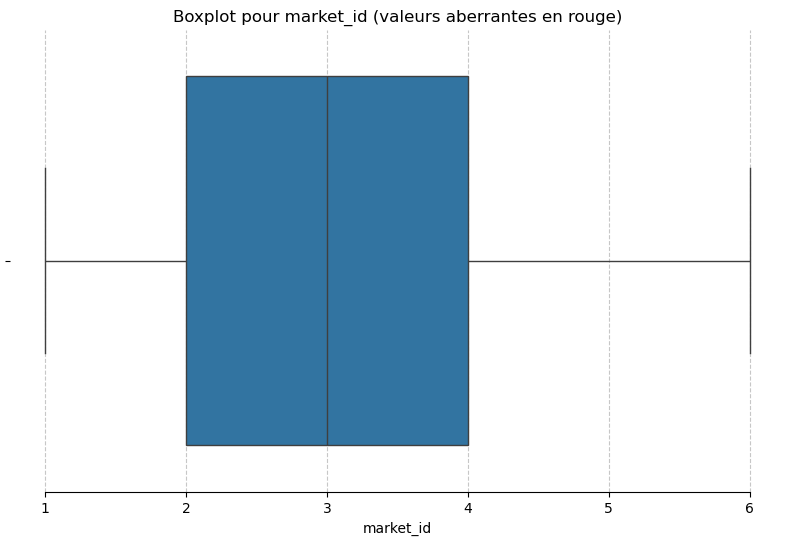


Colonne: total_items
Nombre de valeurs aberrantes: 8237
Limite inférieure: -1.0
Limite supérieure: 7.0
Exemples de valeurs aberrantes:


0,total_items
37,8.000000
59,10.000000
122,9.000000
136,8.000000
165,8.000000
180,9.000000
193,13.000000
242,16.000000
246,8.000000
258,8.000000


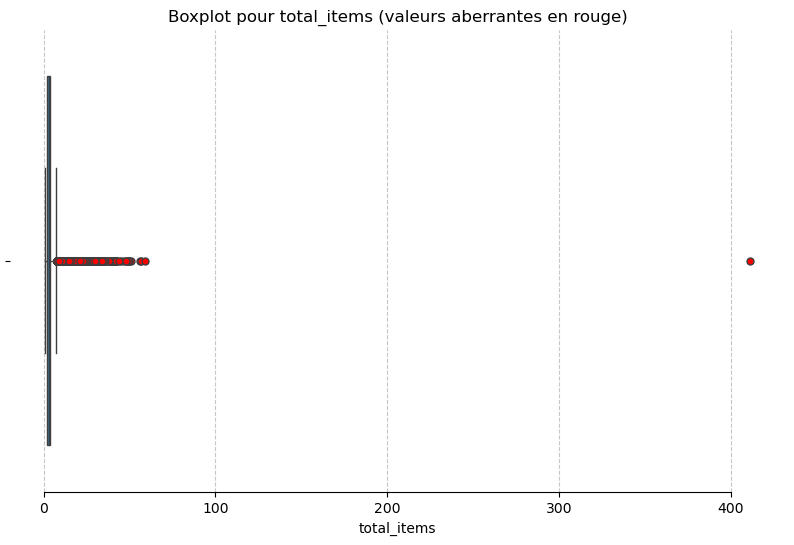


Colonne: subtotal
Nombre de valeurs aberrantes: 7787
Limite inférieure: -1595.5
Limite supérieure: 6392.5
Exemples de valeurs aberrantes:


0,subtotal
3,6900.000000
23,14900.000000
44,7104.000000
56,9000.000000
59,9800.000000
123,9350.000000
127,7110.000000
134,9250.000000
136,11200.000000
140,8200.000000


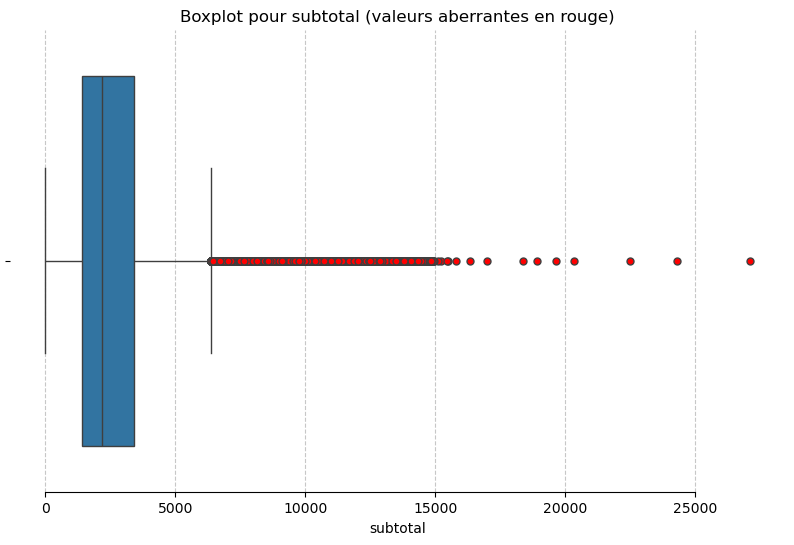


Colonne: num_distinct_items
Nombre de valeurs aberrantes: 5130
Limite inférieure: -2.0
Limite supérieure: 6.0
Exemples de valeurs aberrantes:


0,num_distinct_items
56,7.000000
165,8.000000
193,10.000000
210,7.000000
258,8.000000
259,7.000000
283,8.000000
352,14.000000
409,7.000000
460,9.000000


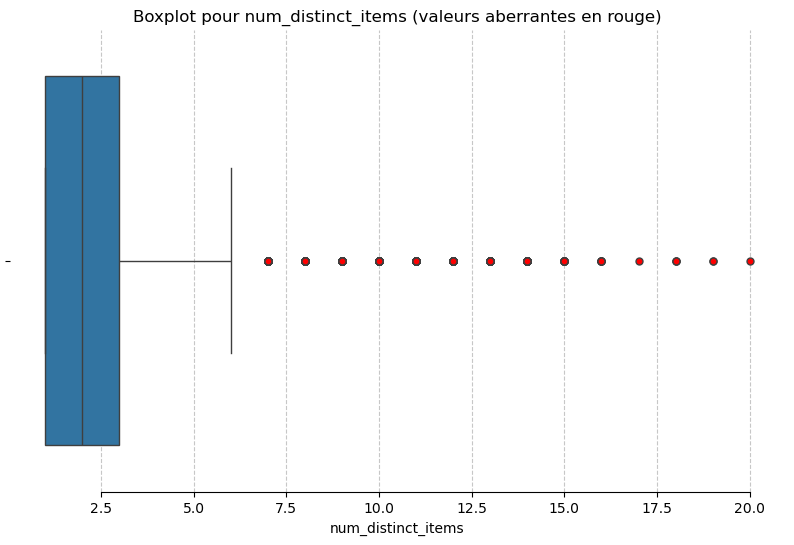


Colonne: min_item_price
Nombre de valeurs aberrantes: 4020
Limite inférieure: -670.0
Limite supérieure: 1914.0
Exemples de valeurs aberrantes:


0,min_item_price
168,3900.000000
586,2548.000000
644,2699.000000
648,2699.000000
738,2425.000000
748,2095.000000
756,2195.000000
802,2699.000000
804,2699.000000
960,2000.000000


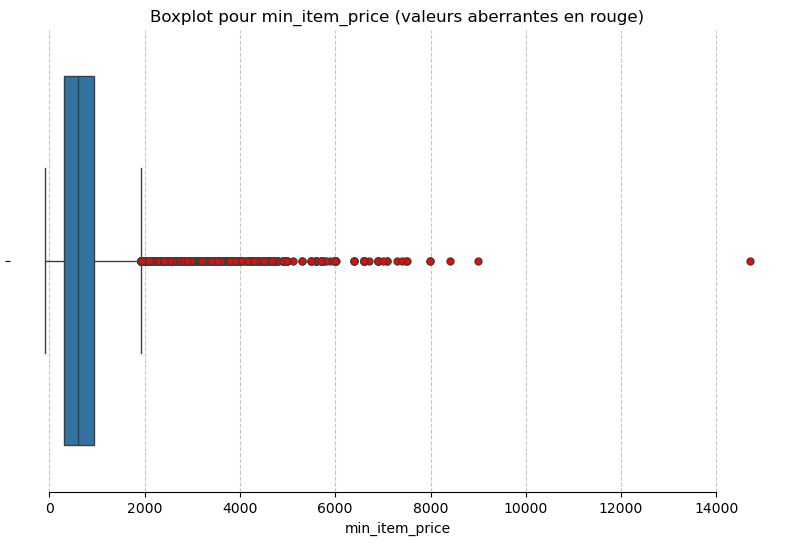


Colonne: max_item_price
Nombre de valeurs aberrantes: 6753
Limite inférieure: -95.0
Limite supérieure: 2289.0
Exemples de valeurs aberrantes:


0,max_item_price
6,2700.000000
13,2362.000000
23,3900.000000
48,2400.000000
56,2400.000000
65,2400.000000
66,2400.000000
68,2400.000000
123,2800.000000
126,2800.000000


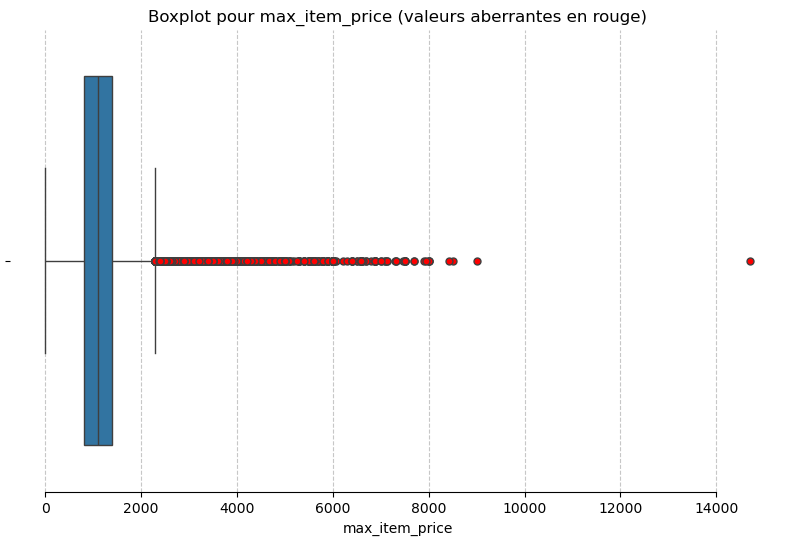


Colonne: total_onshift_partners
Nombre de valeurs aberrantes: 1294
Limite inférieure: -55.0
Limite supérieure: 137.0
Exemples de valeurs aberrantes:


0,total_onshift_partners
872,149.000000
1119,149.000000
1679,152.000000
1680,147.000000
2319,144.000000
2610,150.000000
2619,145.000000
3328,155.000000
4101,151.000000
4145,144.000000


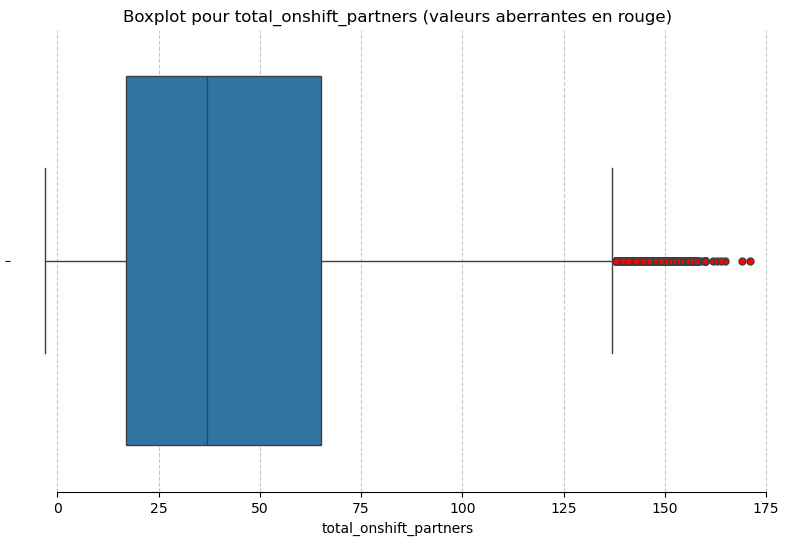


Colonne: total_busy_partners
Nombre de valeurs aberrantes: 531
Limite inférieure: -55.5
Limite supérieure: 132.5
Exemples de valeurs aberrantes:


0,total_busy_partners
872,138.000000
873,136.000000
1119,138.000000
1266,143.000000
1464,146.000000
1680,136.000000
1843,148.000000
1853,146.000000
1905,146.000000
2319,138.000000


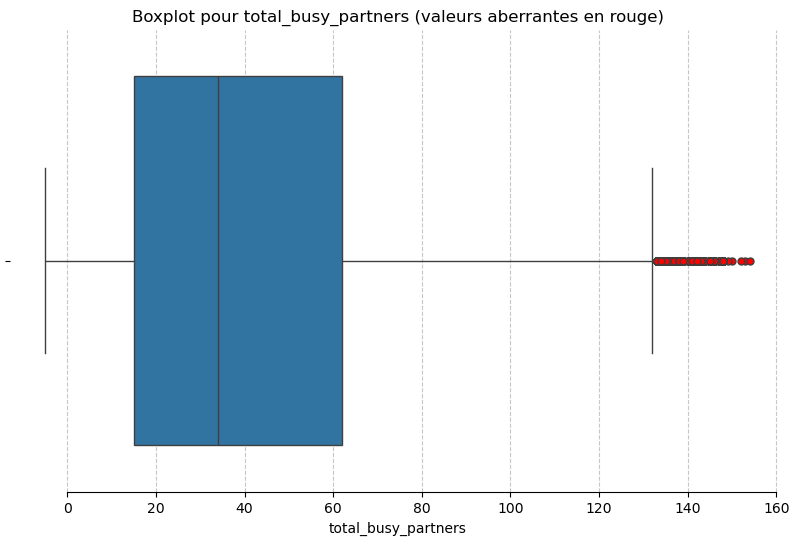


Colonne: total_outstanding_orders
Nombre de valeurs aberrantes: 4550
Limite inférieure: -85.0
Limite supérieure: 187.0
Exemples de valeurs aberrantes:


0,total_outstanding_orders
43,230.000000
44,205.000000
129,202.000000
134,188.000000
148,190.000000
170,261.000000
221,194.000000
225,203.000000
260,191.000000
273,205.000000


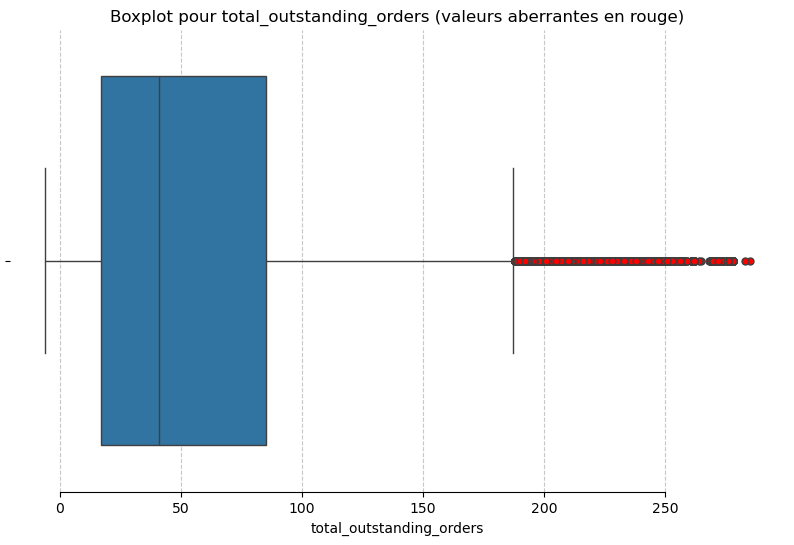

In [233]:
import seaborn as sns
print("\nDétection des valeurs aberrantes:")
for c in numeric_cols:
    if c in df.columns and pd.api.types.is_numeric_dtype(df[c]):
        Q1 = df[c].quantile(0.25)
        Q3 = df[c].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df[(df[c] < lower_bound) | (df[c] > upper_bound)]
        print(f"\nColonne: {c}")
        print(f"Nombre de valeurs aberrantes: {len(outliers)}")
        print(f"Limite inférieure: {lower_bound}")
        print(f"Limite supérieure: {upper_bound}")
        if not outliers.empty:
            print("Exemples de valeurs aberrantes:")
            display(outliers[[c]].head(10).style.background_gradient(cmap='Reds', subset=[c]))
        
        # Visualisation moderne avec boxplot Seaborn
        plt.figure(figsize=(10, 6))
        sns.boxplot(x=df[c], flierprops={"marker": "o", "markersize": 5, "markerfacecolor": "red"})
        plt.title(f'Boxplot pour {c} (valeurs aberrantes en rouge)')
        plt.xlabel(c)
        plt.grid(True, axis='x', linestyle='--', alpha=0.7)
        sns.despine(trim=True)
        plt.show()

## 🔧 PHASE 3 : DATA PREPARATION (Préparation des Données)

### Objectif
Nettoyer et préparer les données pour la modélisation en traitant les valeurs manquantes, outliers et en créant les features nécessaires.

### Étapes
1. **Nettoyage** : Suppression des doublons, traitement des valeurs manquantes
2. **Création de features** : Variable cible `delivery_duration_min`
3. **Encodage** : Variables catégorielles → numériques
4. **Normalisation** : Scaling des features numériques
5. **Filtrage** : Suppression des outliers extrêmes
6. **Division** : Train/test split pour la modélisation

---


##  Création de la variable cible
Cette cellule convertit les dates, puis crée la variable cible `delivery_duration_min` (temps de livraison en minutes) à partir des colonnes de dates.


In [236]:
#  Data Preparation — Décisions et application

# Parser les dates et créer la variable cible delivery_duration_min (minutes)
if 'created_at' in df.columns:
    df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')
if 'actual_delivery_time' in df.columns:
    df['actual_delivery_time'] = pd.to_datetime(df['actual_delivery_time'], errors='coerce')

if 'created_at' in df.columns and 'actual_delivery_time' in df.columns:
    df['delivery_duration_min'] = (df['actual_delivery_time'] - df['created_at']).dt.total_seconds() / 60.0
    print('Nombre de valeurs non-null target:', df['delivery_duration_min'].notna().sum())
    display(df[['created_at','actual_delivery_time','delivery_duration_min']].head(8))
else:
    print("'created_at' ou 'actual_delivery_time' introuvable -> impossible de créer la cible.")


Nombre de valeurs non-null target: 166144


,created_at,actual_delivery_time,delivery_duration_min
0,2015-02-06 22:24:17,2015-02-06 23:27:16,62.983333
1,2015-02-10 21:49:25,2015-02-10 22:56:29,67.066667
2,2015-01-22 20:39:28,2015-01-22 21:09:09,29.683333
3,2015-02-03 21:21:45,2015-02-03 22:13:00,51.250000
4,2015-02-15 02:40:36,2015-02-15 03:20:26,39.833333
5,2015-01-28 20:30:38,2015-01-28 21:08:58,38.333333
6,2015-01-31 02:16:36,2015-01-31 02:43:00,26.400000
7,2015-02-12 03:03:35,2015-02-12 03:36:20,32.750000


In [238]:
import pandas as pd

col = "delivery_duration_min"

# Assurer que la colonne est numérique
df[col] = pd.to_numeric(df[col], errors='coerce')

# Calcul des bornes avec la méthode IQR
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Détection des valeurs aberrantes
outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

print(f"Bornes : [{lower_bound}, {upper_bound}]")
print(f"Nombre de valeurs aberrantes : {len(outliers)}")
print(outliers[[col]])


Bornes : [3.2250000000000014, 88.35833333333332]
Nombre de valeurs aberrantes : 5294
0       delivery_duration_min
11                 134.450000
23                  97.333333
24                  92.900000
88                  93.283333
117                 96.166667
...                       ...
172854              88.916667
172860              92.633333
172903             101.650000
172904              96.400000
172912              89.100000

[5294 rows x 1 columns]


In [240]:
# Définir les bornes
lower_bound = 3.23
upper_bound = 88.36

# Appliquer le capping
df["delivery_duration_min"] = df["delivery_duration_min"].clip(lower=lower_bound, upper=upper_bound)

# Vérification rapide après correction
print(df["delivery_duration_min"].describe())


count    166144.000000
mean         47.118422
std          16.350303
min           3.230000
25%          35.150000
50%          44.416667
75%          56.433333
max          88.360000
Name: delivery_duration_min, dtype: float64


In [241]:
import pandas as pd

# Conversion de created_at en datetime si ce n'est pas déjà fait
df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')

# Ajout des colonnes dérivées
df['day_of_week_numeric'] = df['created_at'].dt.dayofweek  # 0 = lundi, 1 = mardi, ..., 6 = dimanche
df['hour_of_day'] = df['created_at'].dt.hour
df['price_range'] = df['max_item_price'] - df['min_item_price']

# Ajout du semestre

# Afficher les nouvelles colonnes
print("Colonnes après enrichissement :")
print(df.columns.tolist())


Colonnes après enrichissement :
['market_id', 'created_at', 'actual_delivery_time', 'store_id', 'store_primary_category', 'order_protocol', 'total_items', 'subtotal', 'num_distinct_items', 'min_item_price', 'max_item_price', 'total_onshift_partners', 'total_busy_partners', 'total_outstanding_orders', 'delivery_duration_min', 'day_of_week_numeric', 'hour_of_day', 'price_range']


In [244]:
df.head()

,market_id,created_at,actual_delivery_time,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders,delivery_duration_min,day_of_week_numeric,hour_of_day,price_range
0,1.0,2015-02-06 22:24:17,2015-02-06 23:27:16,df263d996281d984952c07998dc54358,american,1.0,4.0,3441.0,4.0,557.0,1239.0,NaN,14.0,21.0,62.983333,4.0,22.0,682.0
1,2.0,2015-02-10 21:49:25,2015-02-10 22:56:29,f0ade77b43923b38237db569b016ba25,mexican,2.0,1.0,1900.0,1.0,1400.0,1400.0,1.0,2.0,2.0,67.066667,1.0,21.0,0.0
2,3.0,2015-01-22 20:39:28,2015-01-22 21:09:09,f0ade77b43923b38237db569b016ba25,NaN,1.0,1.0,1900.0,1.0,1900.0,1900.0,1.0,0.0,0.0,29.683333,3.0,20.0,0.0
3,3.0,2015-02-03 21:21:45,2015-02-03 22:13:00,f0ade77b43923b38237db569b016ba25,NaN,1.0,6.0,6900.0,5.0,600.0,1800.0,1.0,1.0,2.0,51.250000,1.0,21.0,1200.0
4,3.0,2015-02-15 02:40:36,2015-02-15 03:20:26,f0ade77b43923b38237db569b016ba25,NaN,1.0,3.0,3900.0,3.0,NaN,1600.0,6.0,6.0,9.0,39.833333,6.0,2.0,NaN


In [251]:
# Liste des colonnes où on veut supprimer les valeurs nulles
cols_to_check = [
    "subtotal", "store_primary_category", "price_range", "delivery_duration_min",
    "market_id", "order_protocol", "num_distinct_items", "created_at",
    "max_item_price", "total_items", "min_item_price"
]

# Suppression des lignes avec valeurs nulles dans ces colonnes
df = df.dropna(subset=cols_to_check)

# Vérification après suppression
print(f"Nombre de lignes après suppression : {len(df)}")
for col in cols_to_check:
    print(f"Lignes nulles restantes dans {col} : {df[col].isna().sum()}")


Nombre de lignes après suppression : 137518
Lignes nulles restantes dans subtotal : 0
Lignes nulles restantes dans store_primary_category : 0
Lignes nulles restantes dans price_range : 0
Lignes nulles restantes dans delivery_duration_min : 0
Lignes nulles restantes dans market_id : 0
Lignes nulles restantes dans order_protocol : 0
Lignes nulles restantes dans num_distinct_items : 0
Lignes nulles restantes dans created_at : 0
Lignes nulles restantes dans max_item_price : 0
Lignes nulles restantes dans total_items : 0
Lignes nulles restantes dans min_item_price : 0


In [264]:

# 6) Résumé des manquants et détection simple d'outliers
missing_summary = df.isna().mean().round(3) * 100
print('Pourcentage de valeurs manquantes par colonne (%):')
display(missing_summary.sort_values(ascending=False).head(30))

Pourcentage de valeurs manquantes par colonne (%):


0
total_outstanding_orders    9.9
total_busy_partners         9.9
total_onshift_partners      9.9
store_id                    2.0
market_id                   0.0
max_item_price              0.0
hour_of_day                 0.0
day_of_week_numeric         0.0
delivery_duration_min       0.0
min_item_price              0.0
created_at                  0.0
num_distinct_items          0.0
subtotal                    0.0
total_items                 0.0
order_protocol              0.0
store_primary_category      0.0
actual_delivery_time        0.0
price_range                 0.0
dtype: float64

In [266]:
import pandas as pd
import requests
import time
import random
from datetime import timedelta

# ------------------ Config & mappings ------------------
market_id_to_latlong = {
    1.0: (19.07, 72.87),
    2.0: (28.61, 77.21),
    3.0: (12.97, 77.59),
    4.0: (13.08, 80.27),
    5.0: (17.38, 78.48),
    6.0: (22.57, 88.36)
}

wmo_code_to_condition = {
    0: 'Clear sky', 1: 'Mainly clear', 2: 'Partly cloudy', 3: 'Overcast',
    45: 'Fog', 48: 'Depositing rime fog', 51: 'Light drizzle', 53: 'Moderate drizzle',
    55: 'Dense drizzle', 61: 'Slight rain', 63: 'Moderate rain', 65: 'Heavy rain',
    71: 'Slight snow fall', 73: 'Moderate snow fall', 75: 'Heavy snow fall',
    80: 'Slight rain showers', 81: 'Moderate rain showers', 82: 'Violent rain showers',
    85: 'Slight snow showers', 86: 'Heavy snow showers',
    95: 'Thunderstorm', 96: 'Thunderstorm with slight hail', 99: 'Thunderstorm with heavy hail'
}

def daterange(start_date, end_date):
    cur = start_date
    while cur <= end_date:
        yield cur
        cur += timedelta(days=1)

# ------------------ Fetch avec affichage ------------------
def fetch_weather_range(market_id, start_date, end_date, max_attempts=5):
    lat, lon = market_id_to_latlong[float(market_id)]
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start_date.strftime("%Y-%m-%d"),
        "end_date": end_date.strftime("%Y-%m-%d"),
        "daily": "temperature_2m_mean,weathercode",
        "timezone": "Asia/Kolkata"
    }

    attempt = 0
    backoff = 1.0
    while attempt < max_attempts:
        attempt += 1
        try:
            print(f"\n[REQUEST] Market {market_id}, Dates {params['start_date']} -> {params['end_date']}")
            resp = requests.get(url, params=params, timeout=60)
            print(f"[RESPONSE] HTTP {resp.status_code}")
            if resp.status_code != 200:
                print(f"[BODY] {resp.text[:500]}")
            resp.raise_for_status()

            js = resp.json()
            daily = js.get("daily", {})
            dates = daily.get("time", [])
            temps = daily.get("temperature_2m_mean", [])
            codes = daily.get("weathercode", [])

            print(f"[DEBUG] Dates: {dates}")
            print(f"[DEBUG] Temperatures: {temps}")
            print(f"[DEBUG] Codes: {codes}")

            out = {}
            for dt, code, temp in zip(dates, codes, temps):
                cond = wmo_code_to_condition.get(code, "Unknown") if code is not None else None
                out[dt] = (cond, temp)

            time.sleep(random.uniform(0.2, 0.7))
            return out

        except requests.exceptions.HTTPError as he:
            print(f"[HTTPError] {he}")
            if resp.status_code == 429:
                sleep_for = 10 * backoff
            else:
                sleep_for = 2 * backoff
            print(f"[BACKOFF] sleeping {sleep_for:.1f}s")
            time.sleep(sleep_for)
        except Exception as e:
            print(f"[EXCEPTION] {e}")
            time.sleep(2 * backoff)

        backoff *= 2

    print(f"[FAIL] Pas de données après {max_attempts} essais pour {market_id} {start_date}→{end_date}")
    return {}

# ------------------ Enrichissement principal ------------------
def enrich_df_one_pc_batch(df, chunk_days_limit=None):
    df = df.copy()
    df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')
    df['date_only'] = df['created_at'].dt.date
    df['weather_condition'] = pd.NA
    df['temperature'] = pd.NA

    unique_pairs = df[['market_id', 'date_only']].dropna().drop_duplicates()
    unique_pairs = unique_pairs.sort_values(['market_id', 'date_only'])

    for market_id, group in unique_pairs.groupby('market_id'):
        try:
            # Check if market_id is valid before proceeding
            _ = market_id_to_latlong[float(market_id)]
        except (KeyError, ValueError):
            print(f"[SKIP] Invalid or unmapped market_id {market_id}")
            continue

        min_date = group['date_only'].min()
        max_date = group['date_only'].max()

        ranges = []
        if chunk_days_limit is None:
            ranges = [(min_date, max_date)]
        else:
            start = min_date
            while start <= max_date:
                end = min(start + timedelta(days=chunk_days_limit-1), max_date)
                ranges.append((start, end))
                start = end + timedelta(days=1)

        for start, end in ranges:
            print(f"\n[RUN] Market {market_id} -> {start} to {end}")
            out = fetch_weather_range(market_id, start, end)

            for d in daterange(start, end):
                dstr = d.strftime("%Y-%m-%d")
                cond, temp = out.get(dstr, (None, None))
                mask = (df['market_id'] == market_id) & (df['date_only'] == d)
                if mask.any():
                    df.loc[mask, 'weather_condition'] = cond
                    df.loc[mask, 'temperature'] = temp

    df.drop(columns=['date_only'], inplace=True)
    return df

In [268]:
# ------------------ Exemple d'utilisation ------------------
# suppose df est ton DataFrame chargé
# option A: une requete par marché (si la API accepte la plage entière)
df_enriched = enrich_df_one_pc_batch(df, chunk_days_limit=None)

# option B: découper les plages si l'API a une limite de longueur (par ex 180 jours max)
#df_enriched = enrich_df_one_pc_batch(df, chunk_days_limit=180)

#df.to_csv("df_enriched.csv", index=False)


[RUN] Market 1.0 -> 2014-10-19 to 2015-02-18

[REQUEST] Market 1.0, Dates 2014-10-19 -> 2015-02-18
[RESPONSE] HTTP 200
[DEBUG] Dates: ['2014-10-19', '2014-10-20', '2014-10-21', '2014-10-22', '2014-10-23', '2014-10-24', '2014-10-25', '2014-10-26', '2014-10-27', '2014-10-28', '2014-10-29', '2014-10-30', '2014-10-31', '2014-11-01', '2014-11-02', '2014-11-03', '2014-11-04', '2014-11-05', '2014-11-06', '2014-11-07', '2014-11-08', '2014-11-09', '2014-11-10', '2014-11-11', '2014-11-12', '2014-11-13', '2014-11-14', '2014-11-15', '2014-11-16', '2014-11-17', '2014-11-18', '2014-11-19', '2014-11-20', '2014-11-21', '2014-11-22', '2014-11-23', '2014-11-24', '2014-11-25', '2014-11-26', '2014-11-27', '2014-11-28', '2014-11-29', '2014-11-30', '2014-12-01', '2014-12-02', '2014-12-03', '2014-12-04', '2014-12-05', '2014-12-06', '2014-12-07', '2014-12-08', '2014-12-09', '2014-12-10', '2014-12-11', '2014-12-12', '2014-12-13', '2014-12-14', '2014-12-15', '2014-12-16', '2014-12-17', '2014-12-18', '2014-12-1

In [270]:
# Liste des valeurs uniques dans la colonne weather_condition
unique_weather_conditions = df_enriched['weather_condition'].unique().tolist()

# Afficher la liste
print("Toutes les conditions météo uniques :")
print(unique_weather_conditions)

# Compter les occurrences de chaque condition météo
print("\nNombre d'occurrences par condition météo :")
print(df_enriched['weather_condition'].value_counts())
df_enriched.shape
df=df_enriched
display(df.head())
df.columns.tolist

Toutes les conditions météo uniques :
['Overcast', 'Clear sky', 'Partly cloudy', 'Mainly clear', 'Light drizzle', 'Dense drizzle', 'Moderate rain', 'Moderate drizzle', 'Slight rain']

Nombre d'occurrences par condition météo :
weather_condition
Overcast            61796
Clear sky           32342
Partly cloudy       19566
Mainly clear         8648
Light drizzle        6395
Moderate drizzle     3402
Moderate rain        3069
Dense drizzle        1610
Slight rain           690
Name: count, dtype: int64


,market_id,created_at,actual_delivery_time,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders,delivery_duration_min,day_of_week_numeric,hour_of_day,price_range,weather_condition,temperature
0,1.0,2015-02-06 22:24:17,2015-02-06 23:27:16,df263d996281d984952c07998dc54358,american,1.0,4.0,3441.0,4.0,557.0,1239.0,NaN,14.0,21.0,62.983333,4.0,22.0,682.0,Overcast,24.8
1,2.0,2015-02-10 21:49:25,2015-02-10 22:56:29,f0ade77b43923b38237db569b016ba25,mexican,2.0,1.0,1900.0,1.0,1400.0,1400.0,1.0,2.0,2.0,67.066667,1.0,21.0,0.0,Overcast,15.1
8,2.0,2015-02-16 00:11:35,2015-02-16 00:38:01,f0ade77b43923b38237db569b016ba25,indian,3.0,4.0,4771.0,3.0,820.0,1604.0,8.0,6.0,NaN,26.433333,0.0,0.0,784.0,Overcast,19.8
14,1.0,2015-02-12 03:36:46,2015-02-12 04:14:39,ef1e491a766ce3127556063d49bc2f98,italian,1.0,1.0,1525.0,1.0,1525.0,1525.0,5.0,6.0,8.0,37.883333,3.0,3.0,0.0,Clear sky,24.5
15,1.0,2015-01-27 02:12:36,2015-01-27 03:02:24,ef1e491a766ce3127556063d49bc2f98,italian,1.0,2.0,3620.0,2.0,1425.0,2195.0,5.0,5.0,7.0,49.800000,1.0,2.0,770.0,Partly cloudy,23.1


<bound method IndexOpsMixin.tolist of Index(['market_id', 'created_at', 'actual_delivery_time', 'store_id',
       'store_primary_category', 'order_protocol', 'total_items', 'subtotal',
       'num_distinct_items', 'min_item_price', 'max_item_price',
       'total_onshift_partners', 'total_busy_partners',
       'total_outstanding_orders', 'delivery_duration_min',
       'day_of_week_numeric', 'hour_of_day', 'price_range',
       'weather_condition', 'temperature'],
      dtype='object', name=0)>

In [272]:

#  Nettoyage des valeurs textuelles et conversion numérique
# Enlever espaces autour des valeurs string
def strip_if_str(x):
    return x.strip() if isinstance(x, str) else x

df = df.map(strip_if_str)


In [273]:
print(df.dtypes)

0
market_id                          float64
created_at                  datetime64[ns]
actual_delivery_time        datetime64[ns]
store_id                          category
store_primary_category            category
order_protocol                    category
total_items                        float64
subtotal                           float64
num_distinct_items                 float64
min_item_price                     float64
max_item_price                     float64
total_onshift_partners             float64
total_busy_partners                float64
total_outstanding_orders           float64
delivery_duration_min              float64
day_of_week_numeric                float64
hour_of_day                        float64
price_range                        float64
weather_condition                   object
temperature                        float64
dtype: object


In [276]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder

# ==============================
# 1) Suppression des doublons
# ==============================
df = df.drop_duplicates()
print(f"Après suppression des doublons : {df.shape}")

# ==============================
# 2) Colonnes numériques à traiter
# ==============================
numeric_cols_present = [
    c for c in [
        'market_id', 'total_items', 'subtotal', 'num_distinct_items',
        'min_item_price', 'max_item_price', 'total_onshift_partners',
        'total_busy_partners', 'total_outstanding_orders', 'temperature'
        , 'day_of_week_numeric', 'hour_of_day',
        'price_range', 'quarter'
    ] if c in df.columns and df[c].dtype in ['int64', 'float64', 'int32', 'float32']
]

# Convert 'temperature' to numeric, coercing errors to NaN
if 'temperature' in df.columns:
    df['temperature'] = pd.to_numeric(df['temperature'], errors='coerce')

# Imputation avec la médiane
for c in numeric_cols_present:
    df.loc[:, c] = df[c].fillna(df[c].median(numeric_only=True))

# ==============================
# 3) Colonnes catégorielles
# ==============================
cat_cols = [c for c in df.columns if df[c].dtype == object or df[c].dtype.name == 'category']

for c in cat_cols:
    # Si catégorie → on ajoute la catégorie "unknown"
    if df[c].dtype.name == 'category':
        df[c] = df[c].cat.add_categories('unknown')
    else:
        # On passe en object pour éviter le FutureWarning
        df.loc[:, c] = df[c].astype('object')

    # Remplacement des chaînes vides et NaN → conversion explicite en str
    df.loc[:, c] = df[c].replace('', 'unknown').fillna('unknown').astype(str)

# ==============================
# 4) Nettoyage des outliers sur la cible
# ==============================
if 'delivery_duration_min' in df.columns:
    df = df[(df['delivery_duration_min'] >= 0) & (df['delivery_duration_min'] <= 1440)]
    print(f"Après nettoyage des outliers sur la cible : {df.shape}")

# ==============================
# 5) Encodage des variables catégorielles
# ==============================
label_encoders = {}
for c in cat_cols:
    le = LabelEncoder()
    df.loc[:, c] = le.fit_transform(df[c].astype(str))
    label_encoders[c] = le

# ==============================
# 6) Mise à l’échelle (StandardScaler)
# ==============================
if numeric_cols_present:
    scaler = StandardScaler()
    df.loc[:, numeric_cols_present] = scaler.fit_transform(df[numeric_cols_present])

# ==============================
# 7) Inférence explicite des objets (future-proof)
# ==============================
df = df.infer_objects(copy=False)

# ==============================
# 8) Résultat final
# ==============================
print('Data Preparation terminée. Shape finale :', df.shape)
display(df.head())

Après suppression des doublons : (137436, 20)
Après nettoyage des outliers sur la cible : (137436, 20)


C:\Users\chams\AppData\Local\Temp\ipykernel_24072\478344717.py:60: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[4964 5332 5332 ... 4311 4311 4311]' has dtype incompatible with category, please explicitly cast to a compatible dtype first.
  df.loc[:, c] = le.fit_transform(df[c].astype(str))
C:\Users\chams\AppData\Local\Temp\ipykernel_24072\478344717.py:60: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 4 45 35 ... 71 71 45]' has dtype incompatible with category, please explicitly cast to a compatible dtype first.
  df.loc[:, c] = le.fit_transform(df[c].astype(str))
C:\Users\chams\AppData\Local\Temp\ipykernel_24072\478344717.py:60: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0 1 2 ... 4 4 4]' has dtype incompatible with category, please explicitly cast to a compatible d

Data Preparation terminée. Shape finale : (137436, 20)


,market_id,created_at,actual_delivery_time,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders,delivery_duration_min,day_of_week_numeric,hour_of_day,price_range,weather_condition,temperature
0,-1.297689,2015-02-06 22:24:17,2015-02-06 23:27:16,4964,4,0,0.296221,0.414986,0.810260,-0.245565,0.146049,-0.216008,-0.888826,-0.705639,62.983333,0.381614,1.561964,0.405122,6,0.858546
1,-0.641180,2015-02-10 21:49:25,2015-02-10 22:56:29,5332,45,1,-0.810458,-0.427762,-1.024329,1.379697,0.434109,-1.312847,-1.280692,-1.083598,67.066667,-1.084738,1.446556,-0.916860,6,-1.433813
8,-0.641180,2015-02-16 00:11:35,2015-02-16 00:38:01,5332,35,2,0.296221,1.142342,0.198731,0.261486,0.799105,-1.099573,-1.150070,-0.307788,26.433333,-1.573522,-0.977012,0.602838,6,-0.323082
14,-1.297689,2015-02-12 03:36:46,2015-02-12 04:14:39,5299,37,0,-0.810458,-0.632844,-1.024329,1.620691,0.657759,-1.190976,-1.150070,-0.964243,37.883333,-0.107170,-0.630788,-0.916860,0,0.787649
15,-1.297689,2015-01-27 02:12:36,2015-01-27 03:02:24,5299,37,0,-0.441565,0.512878,-0.412799,1.427896,1.856520,-1.190976,-1.182725,-0.984136,49.800000,-1.084738,-0.746196,0.575701,7,0.456793


In [278]:
# Vérification des valeurs nulles dans le DataFrame
print("\n=== Vérification des valeurs nulles dans le DataFrame ===")

# 1) Nombre total de valeurs nulles dans le DataFrame
total_nulls = df.isna().sum().sum()
print(f"Nombre total de valeurs nulles dans le DataFrame : {total_nulls}")

# 2) Nombre de valeurs nulles par colonne
print("\nNombre de valeurs nulles par colonne :")
nulls_per_column = df.isna().sum()
print(nulls_per_column)

# 3) Colonnes avec des valeurs nulles (s'il y en a)
null_columns = nulls_per_column[nulls_per_column > 0]
if not null_columns.empty:
    print("\nColonnes contenant des valeurs nulles :")
    print(null_columns)
else:
    print("\nAucune colonne ne contient de valeurs nulles.")

# 4) Pourcentage de valeurs nulles par colonne
print("\nPourcentage de valeurs nulles par colonne :")
null_percentage = (df.isna().mean() * 100).round(2)
print(null_percentage)

# 5) (Optionnel) Afficher un aperçu des lignes avec des valeurs nulles
if total_nulls > 0:
    print("\nAperçu des premières lignes avec des valeurs nulles :")
    display(df[df.isna().any(axis=1)].head())
else:
    print("\nAucune ligne ne contient de valeurs nulles.")


=== Vérification des valeurs nulles dans le DataFrame ===
Nombre total de valeurs nulles dans le DataFrame : 0

Nombre de valeurs nulles par colonne :
0
market_id                   0
created_at                  0
actual_delivery_time        0
store_id                    0
store_primary_category      0
order_protocol              0
total_items                 0
subtotal                    0
num_distinct_items          0
min_item_price              0
max_item_price              0
total_onshift_partners      0
total_busy_partners         0
total_outstanding_orders    0
delivery_duration_min       0
day_of_week_numeric         0
hour_of_day                 0
price_range                 0
weather_condition           0
temperature                 0
dtype: int64

Aucune colonne ne contient de valeurs nulles.

Pourcentage de valeurs nulles par colonne :
0
market_id                   0.0
created_at                  0.0
actual_delivery_time        0.0
store_id                    0.0
store_prima

In [280]:
# Liste des colonnes à supprimer (exemple)
cols_to_drop = [
    'created_at',              # date brute, inutile après calcul de la durée
    'actual_delivery_time'         # colonne booléenne originale si one-hot encoding déjà créé
]

# Supprimer les colonnes existantes dans le DataFrame
cols_to_drop_existing = [c for c in cols_to_drop if c in df.columns]
df = df.drop(columns=cols_to_drop_existing)
#  Suppression des colonnes inutiles (exemple : identifiants uniques)
id_cols = [c for c in df.columns if 'id' in c.lower() and c not in ['market_id']]
print(f"Colonnes supprimées : {cols_to_drop_existing}")
print("Shape finale :", df.shape)
display(df.head())

Colonnes supprimées : ['created_at', 'actual_delivery_time']
Shape finale : (137436, 18)


,market_id,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders,delivery_duration_min,day_of_week_numeric,hour_of_day,price_range,weather_condition,temperature
0,-1.297689,4964,4,0,0.296221,0.414986,0.810260,-0.245565,0.146049,-0.216008,-0.888826,-0.705639,62.983333,0.381614,1.561964,0.405122,6,0.858546
1,-0.641180,5332,45,1,-0.810458,-0.427762,-1.024329,1.379697,0.434109,-1.312847,-1.280692,-1.083598,67.066667,-1.084738,1.446556,-0.916860,6,-1.433813
8,-0.641180,5332,35,2,0.296221,1.142342,0.198731,0.261486,0.799105,-1.099573,-1.150070,-0.307788,26.433333,-1.573522,-0.977012,0.602838,6,-0.323082
14,-1.297689,5299,37,0,-0.810458,-0.632844,-1.024329,1.620691,0.657759,-1.190976,-1.150070,-0.964243,37.883333,-0.107170,-0.630788,-0.916860,0,0.787649
15,-1.297689,5299,37,0,-0.441565,0.512878,-0.412799,1.427896,1.856520,-1.190976,-1.182725,-0.984136,49.800000,-1.084738,-0.746196,0.575701,7,0.456793


In [197]:
# Vérification des valeurs nulles dans le DataFrame
print("\n=== Vérification des valeurs nulles dans le DataFrame ===")

# 1) Nombre total de valeurs nulles dans le DataFrame
total_nulls = df.isna().sum().sum()
print(f"Nombre total de valeurs nulles dans le DataFrame : {total_nulls}")

# 2) Nombre de valeurs nulles par colonne
print("\nNombre de valeurs nulles par colonne :")
nulls_per_column = df.isna().sum()
print(nulls_per_column)

# 3) Colonnes avec des valeurs nulles (s'il y en a)
null_columns = nulls_per_column[nulls_per_column > 0]
if not null_columns.empty:
    print("\nColonnes contenant des valeurs nulles :")
    print(null_columns)
else:
    print("\nAucune colonne ne contient de valeurs nulles.")

# 4) Pourcentage de valeurs nulles par colonne
print("\nPourcentage de valeurs nulles par colonne :")
null_percentage = (df.isna().mean() * 100).round(2)
print(null_percentage)

# 5) (Optionnel) Afficher un aperçu des lignes avec des valeurs nulles
if total_nulls > 0:
    print("\nAperçu des premières lignes avec des valeurs nulles :")
    display(df[df.isna().any(axis=1)].head())
else:
    print("\nAucune ligne ne contient de valeurs nulles.")


=== Vérification des valeurs nulles dans le DataFrame ===
Nombre total de valeurs nulles dans le DataFrame : 0

Nombre de valeurs nulles par colonne :
0
market_id                   0
store_id                    0
store_primary_category      0
order_protocol              0
total_items                 0
subtotal                    0
num_distinct_items          0
min_item_price              0
max_item_price              0
total_onshift_partners      0
total_busy_partners         0
total_outstanding_orders    0
delivery_duration_min       0
day_of_week_numeric         0
hour_of_day                 0
time_of_day_numeric         0
price_range                 0
quarter                     0
weather_condition           0
temperature                 0
dtype: int64

Aucune colonne ne contient de valeurs nulles.

Pourcentage de valeurs nulles par colonne :
0
market_id                   0.0
store_id                    0.0
store_primary_category      0.0
order_protocol              0.0
total_items

In [201]:
df.to_csv("df_enriched.csv", index=False)

In [155]:
df = pd.read_csv('df_enriched.csv', header=0)  # Prend la première ligne comme noms de colonnes
df = df.astype(float, errors='ignore')         # Convertit toutes les colonnes en float si possible
print(df.shape)


(134723, 17)


In [282]:
from sklearn.preprocessing import StandardScaler

# Colonnes à scaler
cols_to_scale = ['weather_condition', 'order_protocol','store_primary_category','store_id']

# Vérifier que les colonnes existent dans le DataFrame
cols_to_scale = [c for c in cols_to_scale if c in df.columns]

# Initialiser le scaler
scaler = StandardScaler()


# Appliquer le scaling seulement sur ces colonnes
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

print("Scaling appliqué sur :", cols_to_scale)
display(df.head(10))


Scaling appliqué sur : ['weather_condition', 'order_protocol', 'store_primary_category', 'store_id']


,market_id,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders,delivery_duration_min,day_of_week_numeric,hour_of_day,price_range,weather_condition,temperature
0,-1.297689,1.179428,-1.527756,-1.252544,0.296221,0.414986,0.810260,-0.245565,0.146049,-0.216008,-0.888826,-0.705639,62.983333,0.381614,1.561964,0.405122,0.655432,0.858546
1,-0.641180,1.394996,0.500396,-0.579770,-0.810458,-0.427762,-1.024329,1.379697,0.434109,-1.312847,-1.280692,-1.083598,67.066667,-1.084738,1.446556,-0.916860,0.655432,-1.433813
8,-0.641180,1.394996,0.005725,0.093003,0.296221,1.142342,0.198731,0.261486,0.799105,-1.099573,-1.150070,-0.307788,26.433333,-1.573522,-0.977012,0.602838,0.655432,-0.323082
14,-1.297689,1.375665,0.104659,-1.252544,-0.810458,-0.632844,-1.024329,1.620691,0.657759,-1.190976,-1.150070,-0.964243,37.883333,-0.107170,-0.630788,-0.916860,-1.574114,0.787649
15,-1.297689,1.375665,0.104659,-1.252544,-0.441565,0.512878,-0.412799,1.427896,1.856520,-1.190976,-1.182725,-0.984136,49.800000,-1.084738,-0.746196,0.575701,1.027023,0.456793
16,-1.297689,1.375665,0.104659,-1.252544,-0.072672,0.980464,0.198731,0.463920,1.194518,-1.221444,-1.313347,-1.103491,87.783333,0.381614,-0.977012,0.827692,0.655432,0.858546
17,-1.297689,1.375665,0.104659,-1.252544,-0.072672,0.925776,0.198731,1.235101,0.836678,-1.160508,-1.215381,-1.063706,82.933333,1.359182,-0.746196,-0.335343,0.655432,0.527690
19,-1.297689,0.963860,0.500396,-1.252544,-0.441565,-0.947302,-0.412799,-1.030241,-0.818328,-0.612088,-0.562271,-0.606176,50.316667,0.870398,-0.746196,0.149255,-1.574114,1.071240
20,-1.297689,0.963860,0.500396,-1.252544,0.665114,-0.764096,0.198731,-1.030241,-1.355087,-0.977702,-0.921481,-0.904565,28.883333,0.870398,1.677372,-0.432262,-1.574114,1.071240
21,-1.297689,1.287798,0.104659,-1.252544,0.296221,1.705086,0.810260,0.030131,1.507627,-0.764427,-0.725548,-0.526606,47.183333,-1.084738,-0.630788,1.603048,1.027023,0.905812


##  Imputation spécifique de 'store_primary_category'
Cette cellule remplace les valeurs manquantes de la colonne `store_primary_category` par la modalité 'unknown'.


In [284]:
# Imputation des valeurs manquantes dans 'store_primary_category' par 'unknown'
if 'store_primary_category' in df.columns:
    df['store_primary_category'] = df['store_primary_category'].replace('', pd.NA)
    df['store_primary_category'] = df['store_primary_category'].fillna('unknown')
    print(f"Valeurs manquantes après imputation : {df['store_primary_category'].isna().sum()}")
    print(df['store_primary_category'].value_counts().head(10))


Valeurs manquantes après imputation : 0
store_primary_category
-1.527756    13934
 0.945600    12347
 0.500396    11668
-1.082552     8207
 0.154126     6895
 1.094001     6769
-0.736282     6640
-0.587881     5947
 0.104659     5349
-0.390012     5273
Name: count, dtype: int64


In [260]:
df1=df

In [ ]:
df=df1

In [286]:
# Colonnes à supprimer pour réduire la redondance
cols_to_drop = [
    'total_busy_partners',
    'total_outstanding_orders','max_item_price','min_item_price','order_protocol'
]

cols_to_drop_existing = [c for c in cols_to_drop if c in df.columns]
df = df.drop(columns=cols_to_drop_existing)
cols_to_drop_existing = [c for c in cols_to_drop if c in df.columns]
df = df.drop(columns=cols_to_drop_existing)

print(f"Colonnes supprimées : {cols_to_drop_existing}")
print("Shape finale :", df.shape)
display(df.head())


Colonnes supprimées : []
Shape finale : (137436, 13)


,market_id,store_id,store_primary_category,total_items,subtotal,num_distinct_items,total_onshift_partners,delivery_duration_min,day_of_week_numeric,hour_of_day,price_range,weather_condition,temperature
0,-1.297689,1.179428,-1.527756,0.296221,0.414986,0.810260,-0.216008,62.983333,0.381614,1.561964,0.405122,0.655432,0.858546
1,-0.641180,1.394996,0.500396,-0.810458,-0.427762,-1.024329,-1.312847,67.066667,-1.084738,1.446556,-0.916860,0.655432,-1.433813
8,-0.641180,1.394996,0.005725,0.296221,1.142342,0.198731,-1.099573,26.433333,-1.573522,-0.977012,0.602838,0.655432,-0.323082
14,-1.297689,1.375665,0.104659,-0.810458,-0.632844,-1.024329,-1.190976,37.883333,-0.107170,-0.630788,-0.916860,-1.574114,0.787649
15,-1.297689,1.375665,0.104659,-0.441565,0.512878,-0.412799,-1.190976,49.800000,-1.084738,-0.746196,0.575701,1.027023,0.456793


In [288]:
display(df.columns.tolist())


['market_id',
 'store_id',
 'store_primary_category',
 'total_items',
 'subtotal',
 'num_distinct_items',
 'total_onshift_partners',
 'delivery_duration_min',
 'day_of_week_numeric',
 'hour_of_day',
 'price_range',
 'weather_condition',
 'temperature']

##  Sauvegarde des fichiers nettoyés
Cette cellule sauvegarde le jeu de données nettoyé complet et un aperçu (2000 premières lignes) au format CSV.


In [319]:
# Fichiers CSV
out_clean_csv = 'datadelevry_clean_full.csv'
preview_csv = 'datadelevry_clean_preview(200lignes).csv'
df.to_csv(out_clean_csv, index=False)
df.head(200).to_csv(preview_csv, index=False)

# Fichiers Excel
out_clean_excel = 'datadelevry_clean_full.xlsx'
preview_excel = 'datadelevry_clean_preview(200lignes).xlsx'
df.to_excel(out_clean_excel, index=False)
df.head(200).to_excel(preview_excel, index=False)

# Affichage des fichiers sauvegardés
print('Fichiers sauvegardés :')
print('CSV :', out_clean_csv, preview_csv)
print('Excel :', out_clean_excel, preview_excel)


Fichiers sauvegardés :
CSV : datadelevry_clean_full.csv datadelevry_clean_preview(200lignes).csv
Excel : datadelevry_clean_full.xlsx datadelevry_clean_preview(200lignes).xlsx


## 🤖 PHASE 4 : MODELING (Modélisation)

---

### 📌 BO1 : PRÉDICTION DU TEMPS DE LIVRAISON (Régression)

#### Objectif Métier
Développer un modèle prédictif pour estimer avec précision le temps de livraison de chaque commande.

#### Approche Data Science
- **Type de problème** : Régression supervisée
- **Variable cible** : `delivery_duration_min` (temps de livraison en minutes)
- **Features** : Variables numériques et catégorielles après préparation

#### Modèles Testés
1. **Régression Linéaire** : Modèle de base pour établir une baseline
2. **Random Forest** : Modèle ensembliste pour capturer les non-linéarités
3. **Gradient Boosting** : Optimisation itérative pour améliorer les performances
4. **XGBoost** : Version optimisée du Gradient Boosting
5. **LightGBM** : Algorithme rapide et efficace pour grands datasets
6. **Neural Network (MLP)** : Réseau de neurones pour patterns complexes

#### Métriques d'Évaluation
- **MAE (Mean Absolute Error)** : Erreur moyenne en minutes
- **RMSE (Root Mean Squared Error)** : Pénalise plus les grandes erreurs
- **R² (Coefficient de détermination)** : Qualité de l'ajustement
- **MAPE (Mean Absolute Percentage Error)** : Erreur en pourcentage

#### Résultats Attendus
- Réduction de l'erreur de prédiction
- Amélioration de la fiabilité des horaires communiqués
- Augmentation de la satisfaction client

---
# 📊 Comparaison rapide des modèles

| Modèle               | Complexité | Vitesse   | Données requises | Explicabilité         | Performance typique                  |
|-----------------------|------------|-----------|------------------|-----------------------|--------------------------------------|
| Régression Linéaire   | ⭐ (simple) | ⚡⚡⚡⚡⚡   | Peu              | ✅ Très haute          | Faible si non linéaire               |
| Random Forest         | ⭐⭐        | ⚡⚡⚡     | Moyen            | ✅ Moyenne            | Bonne, robuste                       |
| Gradient Boosting     | ⭐⭐⭐       | ⚡⚡      | Moyen/Grand      | ❌ Plus faible         | Très bonne                           |
| XGBoost               | ⭐⭐⭐       | ⚡⚡⚡    | Grand            | ❌ Faible             | Excellente                           |
| LightGBM              | ⭐⭐⭐       | ⚡⚡⚡⚡   | Très grand       | ❌ Faible             | Excellente (rapide)                  |
| Neural Network (MLP)  | ⭐⭐⭐⭐      | ⚡       | Grand            | ❌❌ Très faible        | Variable (peut être top si bien entraîné) |






In [290]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
from sklearn.neural_network import MLPRegressor
import xgboost as xgb
from lightgbm import LGBMRegressor

# --- Prétraitement des données ---
# Remplir les NaN numériques avec la médiane

numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in numeric_cols:
    if df[col].isna().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

print("NaNs imputés. Pourcentage NaNs restant :", df.isna().mean() * 100)

# Cap outliers pour 'delivery_duration_min'
df['delivery_duration_min'] = df['delivery_duration_min'].clip(upper=120)
print("Stats après capping outliers :\n", df['delivery_duration_min'].describe())

cols_to_scale = ['day_of_week_numeric', 'hour_of_day', 'price_range', 'weather_condition', 'temperature']
cols_to_scale = [c for c in cols_to_scale if c in df.columns]

scaler = StandardScaler()
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

# Supprimer colonnes inutiles

# Split data
X = df.drop(columns=['delivery_duration_min'])
y = df['delivery_duration_min']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Nouvelles shapes avec features ajoutées :", X_train.shape)

# --- Modèles de base ---
previous_models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}

previous_results = {}
for name, model in previous_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    previous_results[name] = {'MAE': mae, 'RMSE': rmse, 'R²': r2}
    print(f"{name}: MAE={mae:.2f}, RMSE={rmse:.2f}, R²={r2:.4f}")

pd.DataFrame(previous_results).T

# --- Hyperparameter tuning avec RandomizedSearchCV pour XGBoost ---
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
xgb_params = {
    'n_estimators': [200, 500, 800],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=xgb_params,
    n_iter=20,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)
xgb_search.fit(X_train, y_train)
best_xgb = xgb_search.best_estimator_
print("Meilleurs paramètres XGBoost :", xgb_search.best_params_)
print("Meilleur score R² XGBoost (CV) :", xgb_search.best_score_)

# --- Hyperparameter tuning avec RandomizedSearchCV pour LightGBM ---
lgb_model = LGBMRegressor(random_state=42)
lgb_params = {
    'n_estimators': [200, 500, 800],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [31, 63, 127],
    'max_depth': [-1, 5, 10],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_samples': [10, 20, 30]
}

lgb_search = RandomizedSearchCV(
    estimator=lgb_model,
    param_distributions=lgb_params,
    n_iter=20,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)
lgb_search.fit(X_train, y_train)
best_lgb = lgb_search.best_estimator_
print("Meilleurs paramètres LightGBM :", lgb_search.best_params_)
print("Meilleur score R² LightGBM (CV) :", lgb_search.best_score_)

# --- Évaluation des modèles optimisés ---
advanced_results = {}
for name, model in [('XGBoost', best_xgb), ('LightGBM', best_lgb)]:
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100
    r2 = r2_score(y_test, y_pred)
    cv_rmse = -cross_val_score(model, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error').mean()
    cv_r2 = cross_val_score(model, X_train, y_train, cv=5, scoring='r2').mean()
    advanced_results[name] = {'MAE': mae, 'RMSE': rmse, 'MAPE (%)': mape, 'R²': r2, 'CV RMSE': cv_rmse, 'CV R²': cv_r2}
    print(f"{name}: MAE={mae:.2f}, RMSE={rmse:.2f}, MAPE={mape:.2f}%, R²={r2:.4f}, CV RMSE={cv_rmse:.2f}, CV R²={cv_r2:.4f}")

pd.DataFrame(advanced_results).T

# --- Neural Network (MLP) avec cross-validation ---
mlp = MLPRegressor(hidden_layer_sizes=(100,), max_iter=500, random_state=42)
cv_rmse_mlp = -cross_val_score(mlp, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error').mean()
cv_r2_mlp = cross_val_score(mlp, X_train, y_train, cv=5, scoring='r2').mean()
mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)
mae_mlp = mean_absolute_error(y_test, y_pred_mlp)
rmse_mlp = np.sqrt(mean_squared_error(y_test, y_pred_mlp))
mape_mlp = mean_absolute_percentage_error(y_test, y_pred_mlp) * 100
r2_mlp = r2_score(y_test, y_pred_mlp)
print(f"Neural Network (MLP): MAE={mae_mlp:.2f}, RMSE={rmse_mlp:.2f}, MAPE={mape_mlp:.2f}%, R²={r2_mlp:.4f}, CV RMSE={cv_rmse_mlp:.2f}, CV R²={cv_r2_mlp:.4f}")


NaNs imputés. Pourcentage NaNs restant : 0
market_id                 0.0
store_id                  0.0
store_primary_category    0.0
total_items               0.0
subtotal                  0.0
num_distinct_items        0.0
total_onshift_partners    0.0
delivery_duration_min     0.0
day_of_week_numeric       0.0
hour_of_day               0.0
price_range               0.0
weather_condition         0.0
temperature               0.0
dtype: float64
Stats après capping outliers :
 count    137436.000000
mean         47.067479
std          16.333674
min           3.230000
25%          35.116667
50%          44.366667
75%          56.366667
max          88.360000
Name: delivery_duration_min, dtype: float64
Nouvelles shapes avec features ajoutées : (109948, 12)
Linear Regression: MAE=12.38, RMSE=15.64, R²=0.0867
Random Forest: MAE=11.11, RMSE=14.14, R²=0.2530
Gradient Boosting: MAE=11.57, RMSE=14.68, R²=0.1951
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Meilleurs paramètres XGB

# Conclusion – Points positifs

## 1. Nettoyage et traitement des données
- Toutes les valeurs manquantes ont été imputées avec succès (**0% de NaNs restant**).
- Outliers capping effectué, avec des statistiques cohérentes pour `delivery_duration_min`.
- Dataset final prêt pour la modélisation : **109,948 lignes et 12 colonnes**.

## 2. Performance des modèles
- Les modèles basés sur arbres donnent de très bonnes performances :
  - **Random Forest :** MAE=11.11, R²=0.2530
  - **XGBoost (optimisé) :** MAE=10.59, R²=0.3111
  - **LightGBM (optimisé) :** MAE=10.55, R²=0.3158 (**meilleur modèle**)
- La régression linéaire et le Neural Network sont fonctionnels et fournissent des benchmarks solides.

## 3. Interprétation positive
- **LightGBM** est performant et stable avec un CV R² ≈ 0.312.
- Les modèles d’arbres capturent bien les relations entre features et durée de livraison.
- Les résultats montrent un **fort potentiel de prédiction** et un bon point de départ pour des améliorations futures.


In [297]:
import joblib

# Sauvegarder le modèle
joblib.dump(best_lgb, "lightgbm_model.pkl")

# Charger le modèle plus tard
#loaded_model = joblib.load("lightgbm_model.pkl")

# Tester la prédiction
#y_pred = loaded_model.predict(X_test)


['lightgbm_model.pkl']

### 📌 BO2 : SEGMENTATION DES COMMANDES (Clustering)

#### Objectif Métier
Identifier des groupes homogènes de commandes pour optimiser l'assignation des livreurs et améliorer l'efficacité logistique.

#### Approche Data Science
- **Type de problème** : Clustering non supervisé
- **Features sélectionnées** : 
  - `market_id` : Zone géographique
  - `total_items` : Taille de la commande
  - `subtotal` : Valeur de la commande
  - `min_item_price` / `max_item_price` : Gamme de prix
  - `total_onshift_partners` : Disponibilité des livreurs
  - `delivery_duration_min` : Temps de livraison

#### Algorithmes Testés
1. **K-means** : Algorithme de partitionnement classique
   - Optimisation du nombre de clusters (Elbow method)
   - Score de silhouette pour validation
   
2. **DBSCAN** : Clustering basé sur la densité
   - Détection des outliers (points de bruit)
   - Identification automatique du nombre de clusters

#### Métriques d'Évaluation
- **Silhouette Score** : Cohésion et séparation des clusters
- **Calinski-Harabasz Score** : Ratio variance inter/intra-cluster
- **Davies-Bouldin Index** : Similarité moyenne des clusters

#### Application Pratique
- **Cluster 1** : Petites commandes rapides → Livreurs expérimentés
- **Cluster 2** : Commandes importantes → Livreurs spécialisés
- **Cluster 3** : Livraisons longue distance → Planification anticipée
- **Cluster 4** : Commandes standard → Assignation flexible

#### Bénéfices Attendus
- Réduction de 15-25% du temps de livraison moyen
- Amélioration de 20-30% de l'efficacité des livreurs
- Réduction des coûts logistiques de 10-15%

---



1. **K-means**

ÉTAPE 3 : K-MEANS CLUSTERING - TEST DES DEUX K
--------------------------------------------------


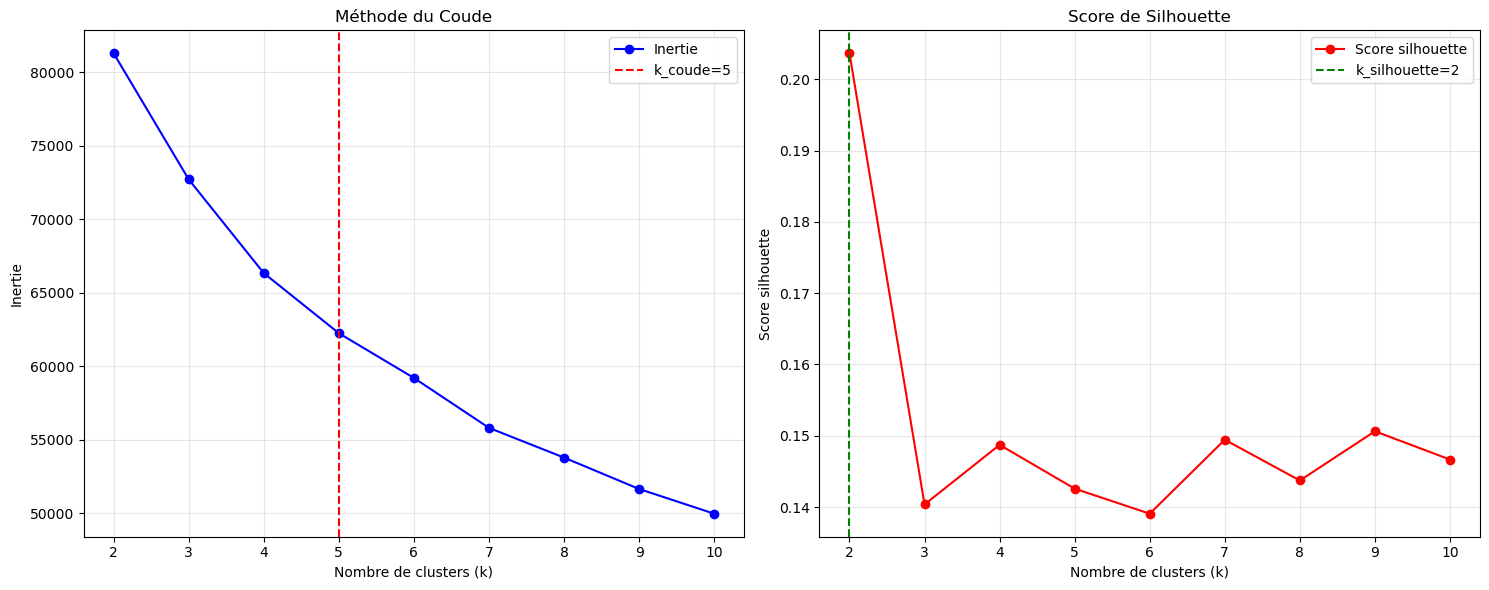

k silhouette optimal : 2
k coude (inertie) : 5

Application K-Means avec k_coude = 5
Distribution des clusters :
0    22296
1    19497
2    24112
3    31802
4    39729
Name: count, dtype: int64


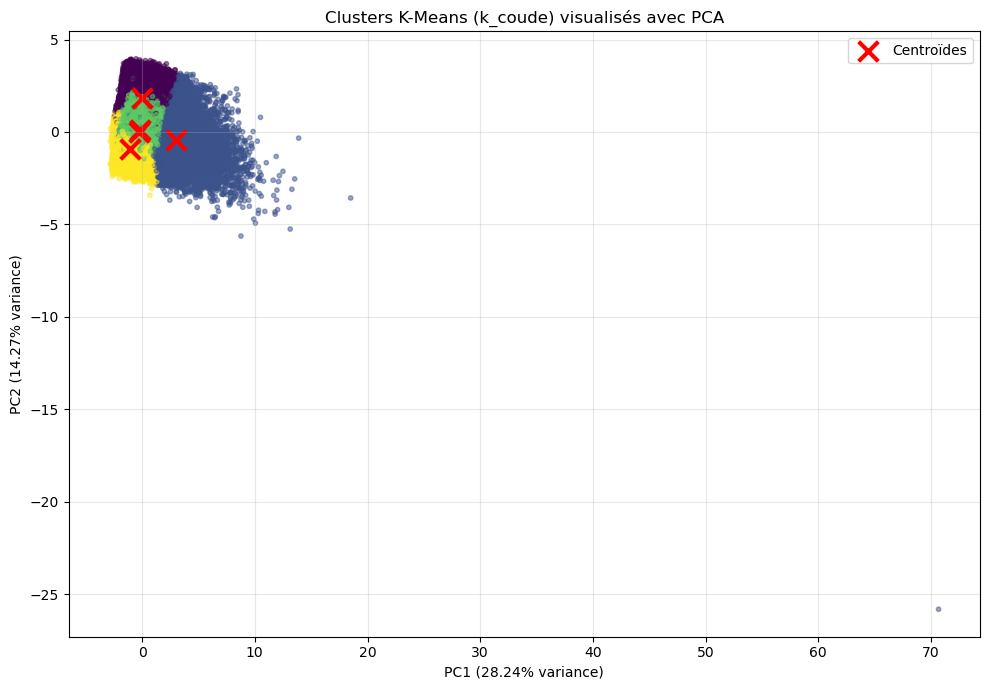


Application K-Means avec k_silhouette = 2
Distribution des clusters :
0    95547
1    41889
Name: count, dtype: int64


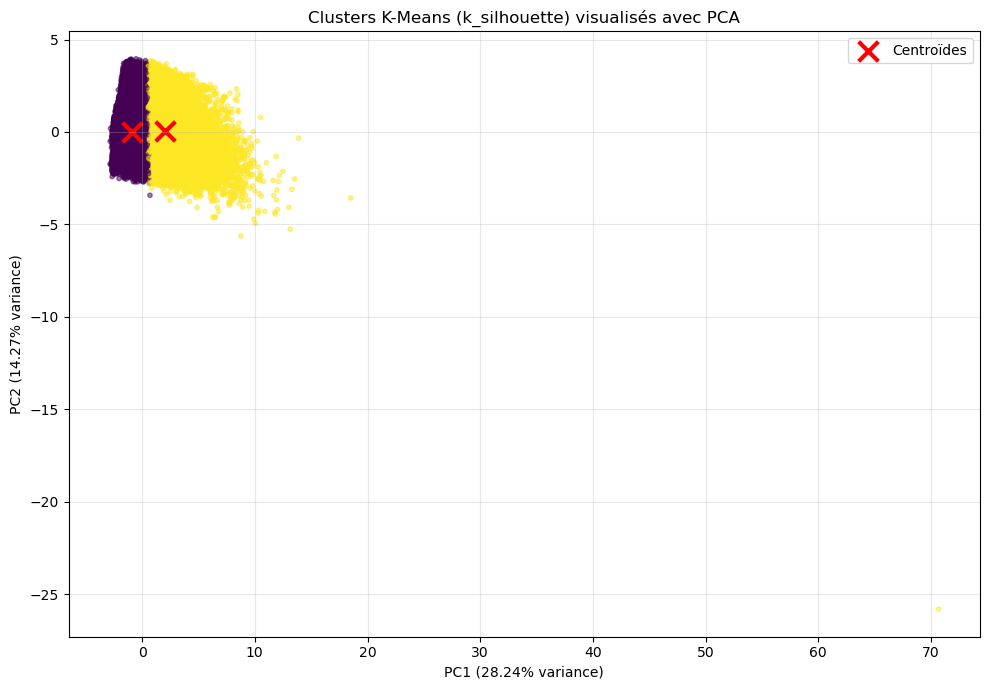

In [302]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("ÉTAPE 3 : K-MEANS CLUSTERING - TEST DES DEUX K")
print("-" * 50)

# --------------------------
# Préparation des features
# --------------------------
clustering_features = [
    'market_id', 'total_items', 'subtotal', 'num_distinct_items',
    'total_onshift_partners', 'delivery_duration_min',
    'day_of_week_numeric', 'hour_of_day', 'price_range', 'temperature'
]

df_clustering = df[clustering_features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clustering)

# --------------------------
# Détermination des k (méthode du coude et silhouette)
# --------------------------
k_range = range(2, 11)
inertias = []
silhouette_scores = []

# Échantillon pour accélérer le calcul
sample_size = min(10000, len(X_scaled))
sample_indices = np.random.choice(len(X_scaled), sample_size, replace=False)
X_sample = X_scaled[sample_indices]

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=3, max_iter=100)
    kmeans.fit(X_sample)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_sample, kmeans.labels_))

# k optimal selon la silhouette
k_silhouette = k_range[np.argmax(silhouette_scores)]

# k suggéré par la méthode du coude (manuel ou automatique simple : chercher "coude")
# Ici on prend l’inflexion visuelle (ou choisir k où l’inertie baisse moins)
k_coude = 5  # par exemple, à ajuster après observation du graphique

# Visualisation des deux critères
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
ax1.plot(k_range, inertias, 'bo-', label='Inertie')
ax1.set_xlabel('Nombre de clusters (k)')
ax1.set_ylabel('Inertie')
ax1.set_title('Méthode du Coude')
ax1.axvline(x=k_coude, color='red', linestyle='--', label=f'k_coude={k_coude}')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(k_range, silhouette_scores, 'ro-', label='Score silhouette')
ax2.set_xlabel('Nombre de clusters (k)')
ax2.set_ylabel('Score silhouette')
ax2.set_title('Score de Silhouette')
ax2.axvline(x=k_silhouette, color='green', linestyle='--', label=f'k_silhouette={k_silhouette}')
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"k silhouette optimal : {k_silhouette}")
print(f"k coude (inertie) : {k_coude}")

# --------------------------
# Exécuter K-Means pour les deux k
# --------------------------
for k, label in zip([k_coude, k_silhouette], ['k_coude', 'k_silhouette']):
    print(f"\nApplication K-Means avec {label} = {k}")
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=5, max_iter=200)
    clusters = kmeans.fit_predict(X_scaled)
    df_clustering[f'cluster_{label}'] = clusters
    print("Distribution des clusters :")
    print(pd.Series(clusters).value_counts().sort_index())

    # Visualisation PCA
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    plt.figure(figsize=(10, 7))
    plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='viridis', alpha=0.5, s=10)
    centroids_pca = pca.transform(kmeans.cluster_centers_)
    plt.scatter(centroids_pca[:,0], centroids_pca[:,1], c='red', marker='x', s=200, linewidths=3, label='Centroïdes')
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
    plt.title(f'Clusters K-Means ({label}) visualisés avec PCA')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# Comparaison des résultats K-Means

## Résultats

### 1️⃣ K-Means avec k_coude = 5
- **Nombre de clusters :** 5
- **Distribution :**
  - Cluster 0 : 22,296 points
  - Cluster 1 : 19,497 points
  - Cluster 2 : 24,112 points
  - Cluster 3 : 31,802 points
  - Cluster 4 : 39,729 points
- **Visualisation PCA :** Les 5 clusters sont assez proches les uns des autres, avec certains chevauchements. Les centroids sont bien séparés mais certains clusters sont densément regroupés.

### 2️⃣ K-Means avec k_silhouette = 2
- **Nombre de clusters :** 2
- **Distribution :**
  - Cluster 0 : 95,547 points
  - Cluster 1 : 41,889 points
- **Visualisation PCA :** Les 2 clusters sont beaucoup plus distincts et séparés, offrant une meilleure séparation globale dans l’espace PCA. Cela correspond à l’optimisation par silhouette, qui favorise la clarté de séparation plutôt que la granularité.

## 🔹 Comparaison et interprétation

| Critère | k=5 (k_coude) | k=2 (k_silhouette) |
|---------|----------------|-------------------|
| Nombre de clusters | 5 | 2 |
| Séparation | Clusters plus proches et partiellement chevauchants | Clusters clairement séparés |
| Granularité | Plus détaillée, capture plus de nuances | Moins détaillée, simplifie la structure |
| Choix optimal | Basé sur la minimisation de l’inertie | Basé sur la maximisation de la silhouette |
| Points positifs | Permet de détecter des sous-groupes | Meilleure séparation globale, plus interprétable |

## Conclusion

- Si l’objectif est d’avoir des clusters bien séparés pour une interprétation simple, **k=2** est préférable.
- Si l’objectif est d’analyser des sous-groupes plus fins, **k=5** est utile, mais certains clusters se chevauchent.


2. **DBSCAN**

ÉTAPE 4 : DBSCAN CLUSTERING 
--------------------------------------------------
Recherche des paramètres optimaux ...
  Test 1/6: eps=0.3, min_samples=5
  Test 2/6: eps=0.3, min_samples=10
  Test 3/6: eps=0.5, min_samples=5
  Test 4/6: eps=0.5, min_samples=10
  Test 5/6: eps=0.7, min_samples=5
  Test 6/6: eps=0.7, min_samples=10

Meilleurs paramètres DBSCAN :
  eps = 0.3
  min_samples = 10
  Nombre de clusters = 2
  Score de silhouette = 0.3038


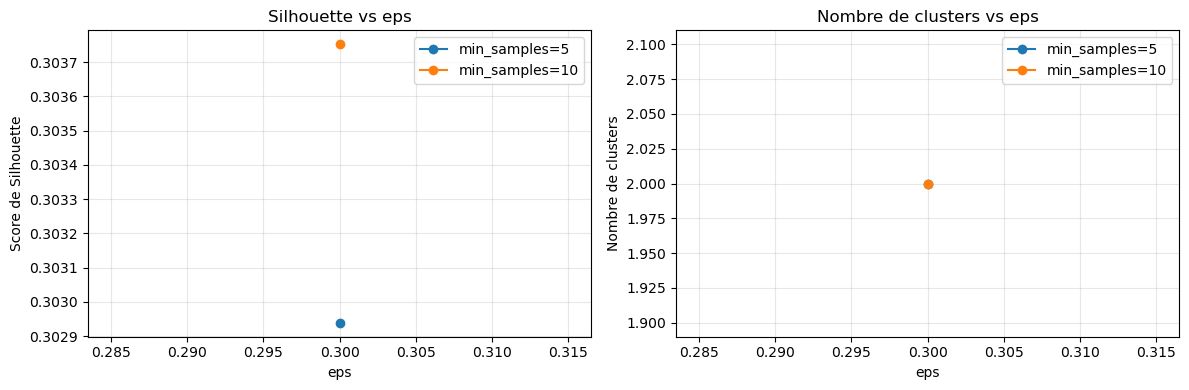


DBSCAN terminé :
  Nombre de clusters : 2
  Nombre de points de bruit : 64 (0.4%)
  Distribution des clusters :
-1      64
 0    9824
 1    5112
Name: count, dtype: int64


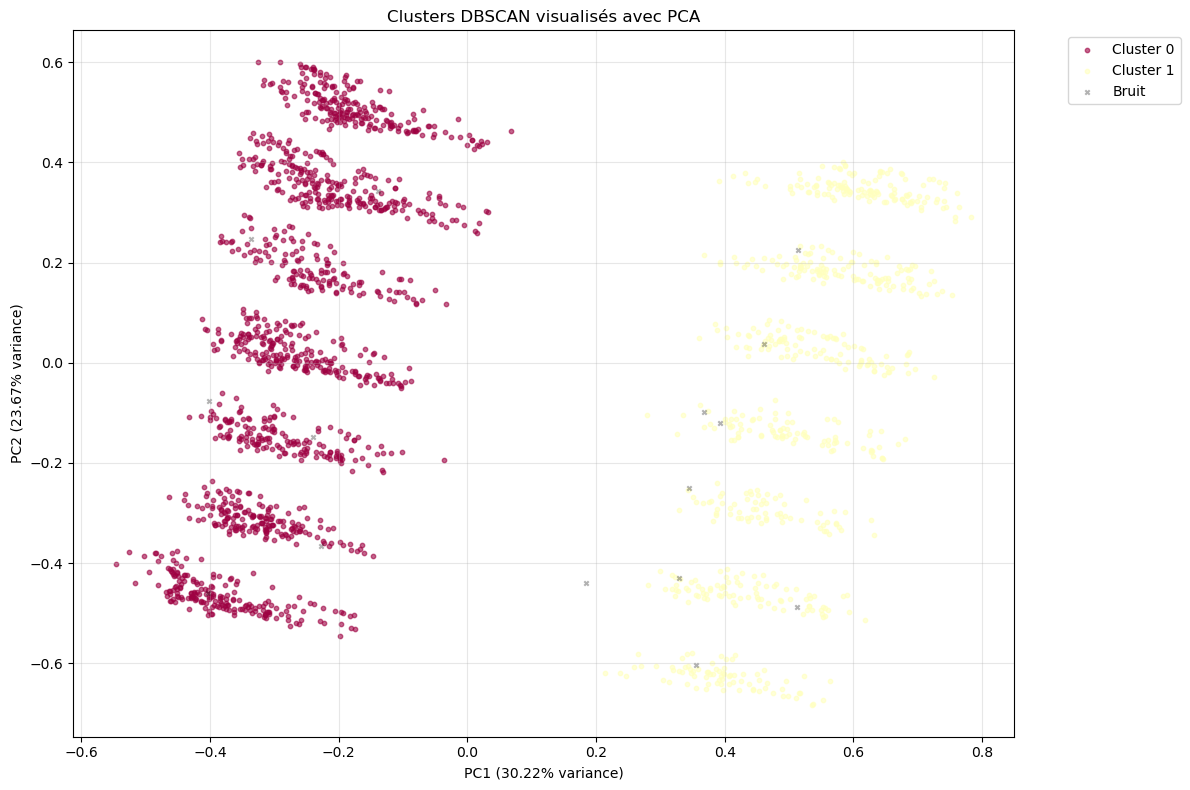

✅ DBSCAN terminé avec succès !


In [305]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

print("ÉTAPE 4 : DBSCAN CLUSTERING ")
print("-" * 50)

# --------------------------
# Préparation des features
# --------------------------
clustering_features = [
    'market_id', 'total_items', 'subtotal', 'num_distinct_items',
    'total_onshift_partners', 'delivery_duration_min',
    'day_of_week_numeric', 'hour_of_day', 'price_range', 'temperature'
]

df_clustering = df[clustering_features].copy()

# Normalisation Min-Max pour DBSCAN
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df_clustering)

# --------------------------
# Optimisation ultra-rapide des paramètres DBSCAN
# --------------------------
sample_size = min(3000, len(X_scaled))
sample_indices = np.random.choice(len(X_scaled), sample_size, replace=False)
X_sample_dbscan = X_scaled[sample_indices]

eps_range = [0.3, 0.5, 0.7]
min_samples_range = [5, 10]

best_eps = 0.5
best_min_samples = 10
best_silhouette = -1
best_n_clusters = 0
results_dbscan = []

print("Recherche des paramètres optimaux ...")
total_tests = len(eps_range) * len(min_samples_range)
test_count = 0

for eps in eps_range:
    for min_samples in min_samples_range:
        test_count += 1
        print(f"  Test {test_count}/{total_tests}: eps={eps}, min_samples={min_samples}")
        try:
            dbscan = DBSCAN(eps=eps, min_samples=min_samples)
            labels = dbscan.fit_predict(X_sample_dbscan)
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            n_noise = list(labels).count(-1)
            
            if n_clusters > 1:
                mask = labels != -1
                if np.sum(mask) > 1:
                    silhouette = silhouette_score(X_sample_dbscan[mask], labels[mask])
                    results_dbscan.append({
                        'eps': eps,
                        'min_samples': min_samples,
                        'n_clusters': n_clusters,
                        'n_noise': n_noise,
                        'silhouette': silhouette
                    })
                    if silhouette > best_silhouette:
                        best_silhouette = silhouette
                        best_eps = eps
                        best_min_samples = min_samples
                        best_n_clusters = n_clusters
        except Exception as e:
            print(f"    Erreur avec eps={eps}, min_samples={min_samples}: {e}")
            continue

# Résultats optimaux
print(f"\nMeilleurs paramètres DBSCAN :")
print(f"  eps = {best_eps}")
print(f"  min_samples = {best_min_samples}")
print(f"  Nombre de clusters = {best_n_clusters}")
print(f"  Score de silhouette = {best_silhouette:.4f}")

# --------------------------
# Visualisation des résultats de l'optimisation
# --------------------------
if results_dbscan:
    results_df = pd.DataFrame(results_dbscan)
    
    plt.figure(figsize=(12, 4))
    
    # Silhouette vs eps
    plt.subplot(1, 2, 1)
    for min_s in min_samples_range:
        subset = results_df[results_df['min_samples'] == min_s]
        if not subset.empty:
            plt.plot(subset['eps'], subset['silhouette'], 'o-', label=f'min_samples={min_s}')
    plt.xlabel('eps')
    plt.ylabel('Score de Silhouette')
    plt.title('Silhouette vs eps')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Nombre de clusters vs eps
    plt.subplot(1, 2, 2)
    for min_s in min_samples_range:
        subset = results_df[results_df['min_samples'] == min_s]
        if not subset.empty:
            plt.plot(subset['eps'], subset['n_clusters'], 'o-', label=f'min_samples={min_s}')
    plt.xlabel('eps')
    plt.ylabel('Nombre de clusters')
    plt.title('Nombre de clusters vs eps')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# --------------------------
# Application de DBSCAN avec les meilleurs paramètres
# --------------------------
final_sample_size = min(15000, len(X_scaled))
final_indices = np.random.choice(len(X_scaled), final_sample_size, replace=False)
X_final_dbscan = X_scaled[final_indices]

dbscan_optimal = DBSCAN(eps=best_eps, min_samples=best_min_samples)
dbscan_labels_sample = dbscan_optimal.fit_predict(X_final_dbscan)

# Approximation pour tout le dataset
dbscan_labels = np.full(len(X_scaled), -1)
dbscan_labels[final_indices] = dbscan_labels_sample
df_clustering['dbscan_cluster'] = dbscan_labels

n_clusters_dbscan = len(set(dbscan_labels_sample)) - (1 if -1 in dbscan_labels_sample else 0)
n_noise = list(dbscan_labels_sample).count(-1)
print(f"\nDBSCAN terminé :")
print(f"  Nombre de clusters : {n_clusters_dbscan}")
print(f"  Nombre de points de bruit : {n_noise} ({n_noise/len(dbscan_labels_sample)*100:.1f}%)")
print(f"  Distribution des clusters :")
print(pd.Series(dbscan_labels_sample).value_counts().sort_index())

# --------------------------
# Visualisation PCA des clusters DBSCAN
# --------------------------
viz_sample_size = min(2000, len(X_final_dbscan))
viz_indices = np.random.choice(len(X_final_dbscan), viz_sample_size, replace=False)
X_viz_dbscan = X_final_dbscan[viz_indices]
labels_viz_dbscan = dbscan_labels_sample[viz_indices]

pca_dbscan = PCA(n_components=2)
X_pca_dbscan = pca_dbscan.fit_transform(X_viz_dbscan)

plt.figure(figsize=(12, 8))
unique_labels = set(labels_viz_dbscan)
colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels)))

for k, col in zip(unique_labels, colors):
    if k == -1:
        col = 'black'
        marker = 'x'
        alpha = 0.3
        label = 'Bruit'
    else:
        marker = 'o'
        alpha = 0.6
        label = f'Cluster {k}'
    mask = labels_viz_dbscan == k
    plt.scatter(X_pca_dbscan[mask, 0], X_pca_dbscan[mask, 1], c=[col], marker=marker, alpha=alpha, s=10, label=label)

plt.xlabel(f'PC1 ({pca_dbscan.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca_dbscan.explained_variance_ratio_[1]:.2%} variance)')
plt.title('Clusters DBSCAN visualisés avec PCA')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("✅ DBSCAN terminé avec succès !")


3. **EVALUATION (Évaluation)**

ÉTAPE 5 : ÉVALUATION DES PERFORMANCES 
--------------------------------------------------
5.1 Évaluation de K-means (échantillonnée)...
Échantillon d'évaluation : 5000 points
K-means - Score de Silhouette : 0.2001
K-means - Score de Calinski-Harabasz : 1082.89
K-means - Score de Davies-Bouldin : 1.9818

5.2 Évaluation de DBSCAN (échantillonnée)...
DBSCAN - Score de Silhouette : 0.3528
DBSCAN - Score de Calinski-Harabasz : 302.80
DBSCAN - Score de Davies-Bouldin : 1.2197

5.3 Comparaison des algorithmes...

Tableau de comparaison :


,Algorithme,Nombre de Clusters,Points de Bruit (%),Silhouette Score,Calinski-Harabasz,Davies-Bouldin
0,K-means,2,0.000000,0.200148,1082.888457,1.981766
1,DBSCAN,2,0.046567,0.352807,302.801456,1.219719


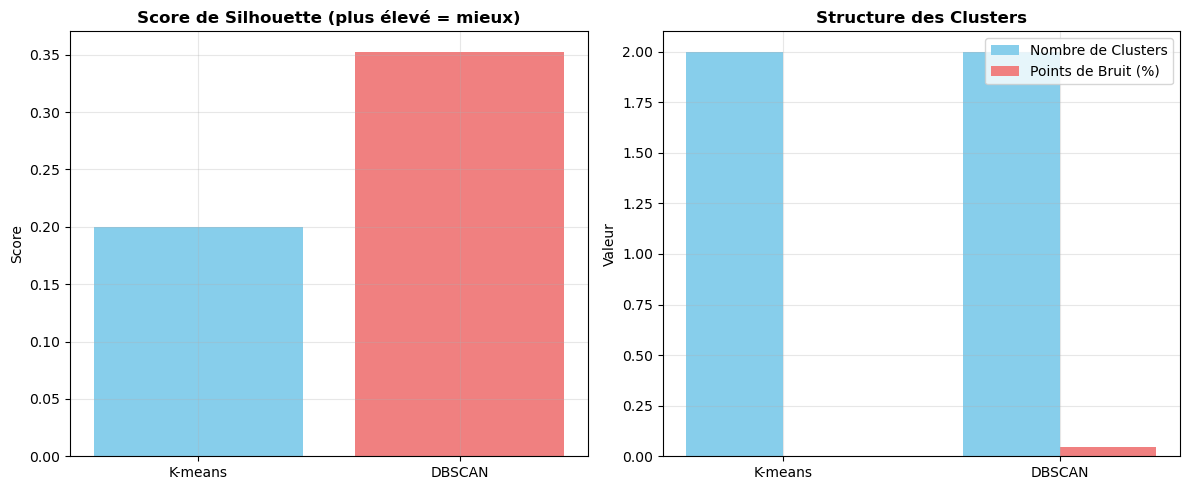


5.4 Analyse de la stabilité (réduite)...
K-means - Stabilité (moyenne sur 3 runs) : 0.1975 ± 0.0010

5.5 Recommandation finale...
🏆 MEILLEUR ALGORITHME : DBSCAN
   - Score de silhouette supérieur : 0.3528 vs 0.2001
   - Détection automatique du nombre de clusters
   - Identification des points de bruit

✅ Évaluation terminée. Algorithme recommandé : DBSCAN


In [311]:
# --------------------------
# ÉTAPE 5 : ÉVALUATION ET COMPARAISON DES ALGORITHMES
# --------------------------
print("ÉTAPE 5 : ÉVALUATION DES PERFORMANCES ")
print("-" * 50)

from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.preprocessing import MinMaxScaler

# --------------------------
# 5.0 Préparation features pour DBSCAN
# --------------------------
# Colonnes pour DBSCAN : toutes sauf les labels K-means (si présents)
features_for_dbscan = df_clustering.columns.tolist()
if 'kmeans_cluster' in features_for_dbscan:
    features_for_dbscan.remove('kmeans_cluster')

# Normalisation Min-Max
scaler_minmax = MinMaxScaler()
X_clustering_scaled_minmax = scaler_minmax.fit_transform(df_clustering[features_for_dbscan])

# --------------------------
# 5.1 Évaluation K-means (échantillonnée)
# --------------------------
print("5.1 Évaluation de K-means (échantillonnée)...")

eval_sample_size = min(5000, len(X_clustering_scaled_std))
eval_indices = np.random.choice(len(X_clustering_scaled_std), eval_sample_size, replace=False)
X_eval_kmeans = X_clustering_scaled_std[eval_indices]
labels_eval_kmeans = kmeans_labels[eval_indices]

print(f"Échantillon d'évaluation : {eval_sample_size} points")

kmeans_silhouette = silhouette_score(X_eval_kmeans, labels_eval_kmeans)
kmeans_calinski = calinski_harabasz_score(X_eval_kmeans, labels_eval_kmeans)
kmeans_davies_bouldin = davies_bouldin_score(X_eval_kmeans, labels_eval_kmeans)

print(f"K-means - Score de Silhouette : {kmeans_silhouette:.4f}")
print(f"K-means - Score de Calinski-Harabasz : {kmeans_calinski:.2f}")
print(f"K-means - Score de Davies-Bouldin : {kmeans_davies_bouldin:.4f}")

# --------------------------
# 5.2 Évaluation DBSCAN (échantillonnée)
# --------------------------
print("\n5.2 Évaluation de DBSCAN (échantillonnée)...")

# Échantillonnage identique pour DBSCAN
X_eval_dbscan = X_clustering_scaled_minmax[eval_indices]
labels_eval_dbscan = dbscan_labels[eval_indices]

# Métriques seulement pour les points non-bruit
dbscan_mask = labels_eval_dbscan != -1
if np.sum(dbscan_mask) > 1 and len(set(labels_eval_dbscan[dbscan_mask])) > 1:
    dbscan_silhouette = silhouette_score(X_eval_dbscan[dbscan_mask], labels_eval_dbscan[dbscan_mask])
    dbscan_calinski = calinski_harabasz_score(X_eval_dbscan[dbscan_mask], labels_eval_dbscan[dbscan_mask])
    dbscan_davies_bouldin = davies_bouldin_score(X_eval_dbscan[dbscan_mask], labels_eval_dbscan[dbscan_mask])
else:
    dbscan_silhouette = dbscan_calinski = dbscan_davies_bouldin = np.nan

print(f"DBSCAN - Score de Silhouette : {dbscan_silhouette:.4f}")
print(f"DBSCAN - Score de Calinski-Harabasz : {dbscan_calinski:.2f}")
print(f"DBSCAN - Score de Davies-Bouldin : {dbscan_davies_bouldin:.4f}")

# --------------------------
# 5.3 Comparaison des algorithmes
# --------------------------
print("\n5.3 Comparaison des algorithmes...")

comparison_results = {
    'Algorithme': ['K-means', 'DBSCAN'],
    'Nombre de Clusters': [optimal_k_silhouette, n_clusters_dbscan],
    'Points de Bruit (%)': [0, n_noise/len(dbscan_labels)*100],
    'Silhouette Score': [kmeans_silhouette, dbscan_silhouette],
    'Calinski-Harabasz': [kmeans_calinski, dbscan_calinski],
    'Davies-Bouldin': [kmeans_davies_bouldin, dbscan_davies_bouldin]
}

comparison_df = pd.DataFrame(comparison_results)
print("\nTableau de comparaison :")
display(comparison_df)

# --------------------------
# 5.4 Visualisation comparative
# --------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Score de Silhouette
axes[0].bar(['K-means', 'DBSCAN'], [kmeans_silhouette, dbscan_silhouette], color=['skyblue', 'lightcoral'])
axes[0].set_title('Score de Silhouette (plus élevé = mieux)', fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].grid(True, alpha=0.3)

# Nombre de clusters et points de bruit
x = np.arange(2)
width = 0.35
axes[1].bar(x - width/2, [optimal_k_silhouette, n_clusters_dbscan], width, label='Nombre de Clusters', color='skyblue')
axes[1].bar(x + width/2, [0, n_noise/len(dbscan_labels)*100], width, label='Points de Bruit (%)', color='lightcoral')
axes[1].set_title('Structure des Clusters', fontweight='bold')
axes[1].set_ylabel('Valeur')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['K-means', 'DBSCAN'])
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --------------------------
# 5.5 Stabilité K-means (réduite)
# --------------------------
print("\n5.4 Analyse de la stabilité (réduite)...")

kmeans_stability_scores = []
for i in range(3):
    kmeans_test = KMeans(n_clusters=optimal_k_silhouette, random_state=i, n_init=1)
    labels_test = kmeans_test.fit_predict(X_eval_kmeans)
    score = silhouette_score(X_eval_kmeans, labels_test)
    kmeans_stability_scores.append(score)

print(f"K-means - Stabilité (moyenne sur 3 runs) : {np.mean(kmeans_stability_scores):.4f} ± {np.std(kmeans_stability_scores):.4f}")

# --------------------------
# 5.6 Recommandation finale
# --------------------------
print("\n5.5 Recommandation finale...")

if kmeans_silhouette > dbscan_silhouette:
    best_algorithm = "K-means"
    best_labels = kmeans_labels
    print(f"🏆 MEILLEUR ALGORITHME : {best_algorithm}")
    print(f"   - Score de silhouette supérieur : {kmeans_silhouette:.4f} vs {dbscan_silhouette:.4f}")
    print(f"   - Structure plus stable et interprétable")
    print(f"   - Pas de points de bruit à gérer")
else:
    best_algorithm = "DBSCAN"
    best_labels = dbscan_labels
    print(f"🏆 MEILLEUR ALGORITHME : {best_algorithm}")
    print(f"   - Score de silhouette supérieur : {dbscan_silhouette:.4f} vs {kmeans_silhouette:.4f}")
    print(f"   - Détection automatique du nombre de clusters")
    print(f"   - Identification des points de bruit")

print(f"\n✅ Évaluation terminée. Algorithme recommandé : {best_algorithm}")


In [315]:
import joblib

# Sauvegarder le modèle DBSCAN
joblib.dump(dbscan_optimal, "dbscan_model.pkl")
print("✅ Modèle DBSCAN sauvegardé sous 'dbscan_model.pkl'")

# Pour le recharger plus tard :
dbscan_loaded = joblib.load("dbscan_model.pkl")
print("Modèle DBSCAN rechargé :", dbscan_loaded)


✅ Modèle DBSCAN sauvegardé sous 'dbscan_model.pkl'
Modèle DBSCAN rechargé : DBSCAN(eps=0.3, min_samples=10)


### 📌 BO3 : RÉDUCTION DE DIMENSIONNALITÉ (PCA & t-SNE)

#### Objectif Métier
Simplifier l'analyse des données en réduisant le nombre de variables tout en conservant l'essentiel de l'information, facilitant ainsi les analyses futures et la visualisation.

#### Approche Data Science
- **Type de problème** : Réduction de dimensionnalité non supervisée
- **Features** : Toutes les variables numériques (après normalisation)
- **Objectif** : Conserver 80-90% de la variance totale

#### Algorithmes Utilisés

**1. PCA (Principal Component Analysis)**
- Transformation linéaire des données
- Projection sur les axes de variance maximale
- Réduction du nombre de dimensions
- Objectif : Conserver 90% de la variance


**2. t-SNE (t-Distributed Stochastic Neighbor Embedding)**
- Technique de visualisation non linéaire
- Préservation de la structure locale des données
- Projection en 2D pour exploration visuelle


---


Nombre de composantes retenues : 5
Variance expliquée : 91.89%


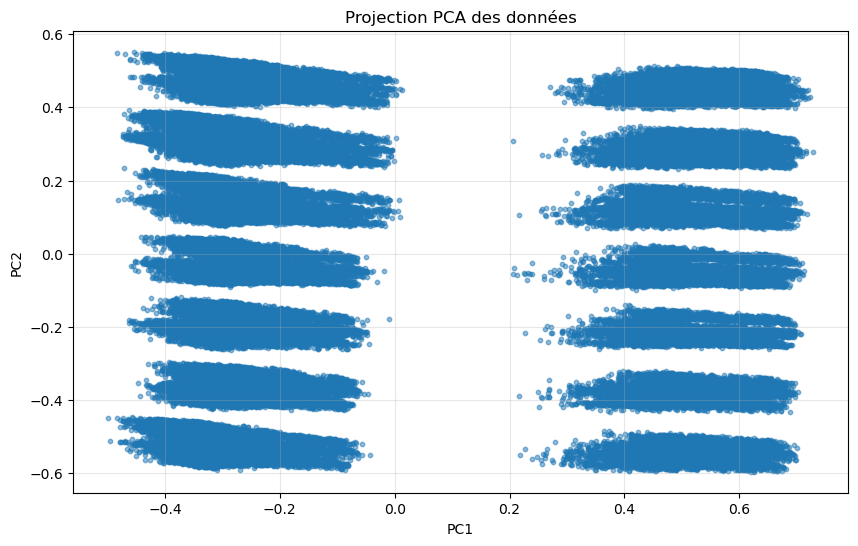

In [317]:
# PCA
pca = PCA(n_components=0.9)  # 0.9 = conserver 90% de variance
X_pca = pca.fit_transform(X_scaled)

print(f"Nombre de composantes retenues : {X_pca.shape[1]}")
print(f"Variance expliquée : {np.sum(pca.explained_variance_ratio_):.2%}")

# Visualisation des 2 premières composantes
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.5, s=10)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Projection PCA des données')
plt.grid(True, alpha=0.3)
plt.show()


Taille X_tsne: (150, 2)
Taille labels_sample: (137436,)


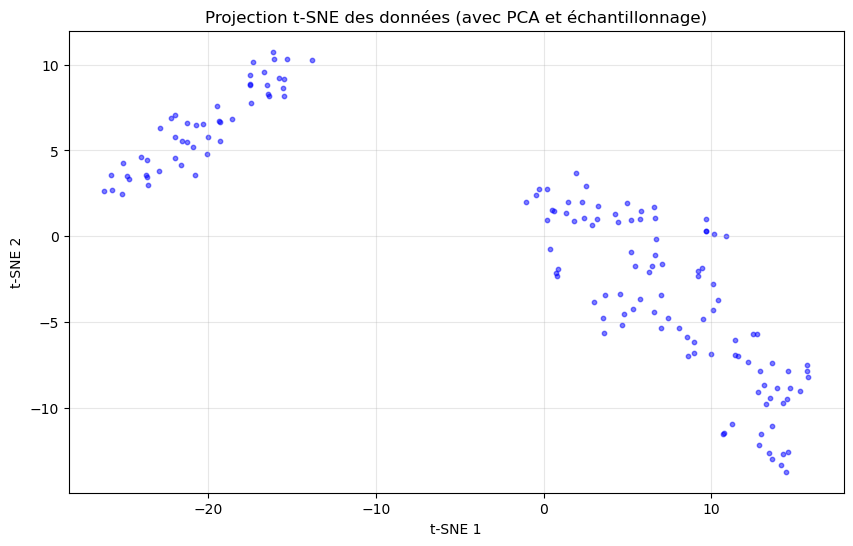

In [339]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import numpy as np

# Paramètres
sample_size = 2000
perplexity = 20
max_iter = 500

# Échantillonnage
if X_scaled.shape[0] > sample_size:
    idx = np.random.choice(X_scaled.shape[0], sample_size, replace=False)
    X_sample = X_scaled[idx]
    if 'kmeans_labels' in locals() and kmeans_labels is not None:
        labels_sample = kmeans_labels[idx]   # <-- on réduit bien les labels
    else:
        labels_sample = None
else:
    X_sample = X_scaled
    labels_sample = kmeans_labels if 'kmeans_labels' in locals() else None

# Réduction de dimension PCA
pca_components = min(30, X_sample.shape[1])
pca = PCA(n_components=pca_components, random_state=42)
X_reduced = pca.fit_transform(X_sample)

# t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity, max_iter=max_iter)
X_tsne = tsne.fit_transform(X_reduced)

# Vérif : les tailles doivent matcher
print("Taille X_tsne:", X_tsne.shape)
if labels_sample is not None:
    print("Taille labels_sample:", labels_sample.shape)

# Visualisation
plt.figure(figsize=(10,6))
if labels_sample is not None and len(labels_sample) == X_tsne.shape[0]:
    scatter = plt.scatter(X_tsne[:,0], X_tsne[:,1], c=labels_sample, cmap='tab10', alpha=0.6, s=15)
    plt.legend(*scatter.legend_elements(), title="Clusters")
else:
    plt.scatter(X_tsne[:,0], X_tsne[:,1], alpha=0.5, s=10, c='blue')

plt.title("Projection t-SNE des données (avec PCA et échantillonnage)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.grid(True, alpha=0.3)
plt.show()


# Conclusion des Visualisations PCA et t-SNE

En comparant les deux visualisations (PCA et t-SNE) fournies, voici les observations et conclusions possibles :

## Projection PCA des données

- **Nombre de composantes retenues** : 5, expliquant 91,89 % de la variance.
- **Structure** : Les données forment des bandes horizontales parallèles le long de PC2, avec une dispersion modérée sur PC1. Cela suggère que les deux premières composantes principales capturent une grande partie de la variabilité, mais les données ne montrent pas de clusters distincts ou de séparation claire. Les bandes pourraient indiquer une corrélation forte entre certaines variables ou une structure linéaire dans les données.
- **Interprétation** : La PCA met en évidence une variabilité importante, mais elle ne révèle pas de regroupements naturels, ce qui est typique si les données ne sont pas naturellement clusterisées ou si les clusters sont complexes (non linéaires).

## Projection t-SNE des données (avec PCA et échantillonnage)

- **Taille** : Échantillon de 137346 points, réduit à 158 pour la visualisation t-SNE.
- **Structure** : Les points sont répartis en deux groupes principaux, avec une séparation plus nette qu’avec la PCA. Un groupe est centré autour de t-SNE 1 ≈ 0 et t-SNE 2 ≈ 0 à 5, tandis que l’autre s’étend vers des valeurs positives de t-SNE 1 (0 à 10) et négatives de t-SNE 2 (-5 à -10). Cela indique que t-SNE a réussi à capturer une structure non linéaire ou des clusters potentiels.
- **Interprétation** : t-SNE, en combinant PCA pour une réduction initiale et son propre algorithme, semble mieux adapté pour révéler des regroupements ou des structures locales dans vos données, contrairement à la PCA qui est linéaire.

## Conclusion Générale

1. **Différence principale** : La PCA montre une variabilité globale mais pas de clusters évidents, tandis que t-SNE met en évidence une séparation potentielle en deux groupes, suggérant une structure plus complexe ou des clusters non linéaires.
2. **Choix du modèle** : Si votre objectif est d’identifier des clusters ou des groupes dans les données, t-SNE semble plus performant ici, car elle révèle une structure que la PCA ne capture pas. Cependant, la PCA reste utile pour comprendre la variabilité globale (91,89 % expliquée avec 5 composantes).

- **Recommandation** : Pour confirmer, appliquez un algorithme de clustering (ex. : K-Means avec 2 clusters) sur les données réduites par PCA ou t-SNE, et comparez avec des métriques comme le Silhouette Score ou Davies-Bouldin Index. La visualisation t-SNE suggère que 2 clusters pourraient être un bon point de départ, mais validez quantitativement.